<a href="https://colab.research.google.com/github/Chillx7/Data_Mining/blob/main/Customer_IT_Support_Ticket_MultiLanguage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## Imports and Data Loading

In [ ]:
# ------------------------------------------------------------------------------
# 1. CORE DATA & VISUALIZATION LIBRARIES
# ------------------------------------------------------------------------------
import math
import time
import warnings

from collections import Counter

import numpy as np
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')  # Suppress convergence/runtime warnings

# ------------------------------------------------------------------------------
# 2. NLP & TEXT MINING TOOLS
# ------------------------------------------------------------------------------
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

# Download required NLTK corpora for TextBlob/tokenization/stopword tasks
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')

# ------------------------------------------------------------------------------
# 3. UNSUPERVISED LEARNING (CLUSTERING)
# ------------------------------------------------------------------------------
from sklearn.cluster import Birch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD

# ------------------------------------------------------------------------------
# 4. SUPERVISED LEARNING
# ------------------------------------------------------------------------------
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

# ------------------------------------------------------------------------------
# 5. MODEL SELECTION, TUNING & EVALUATION
# ------------------------------------------------------------------------------
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------------------------
# 6. RESAMPLING
# ------------------------------------------------------------------------------
from imblearn.over_sampling import SMOTE

# ------------------------------------------------------------------------------
# 7. MODEL EXPORTING
# ------------------------------------------------------------------------------
import joblib

# ------------------------------------------------------------------------------
# CONNECT & LOAD DATA
# ------------------------------------------------------------------------------
try:
    from google.colab import drive
except ImportError:
    drive = None

if drive is not None:
    drive.mount('/content/drive')
else:
    raise ImportError("google.colab is not available. Run this script in Google Colab.")

# NOTE: Update this file path if your CSV is in a different folder!
file_path = '/content/drive/My Drive/Machine Learning/aa_dataset-tickets-multi-lang-5-2-50-version.csv'
df = pd.read_csv(file_path)

print("All Phase 3 libraries successfully imported and NLTK data downloaded!")
print(f"Data loaded successfully. Shape: {df.shape[0]} rows, {df.shape[1]} columns.")

# Explicitly convert date columns (important for min/max and date operations)
date_cols = ['ticket_created_date', 'ticket_resolved_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"Verified: {len(df.columns)} columns loaded.")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Mounted at /content/drive
All Phase 3 libraries successfully imported and NLTK data downloaded!
Data loaded successfully. Shape: 28587 rows, 16 columns.
Verified: 16 columns loaded.


## Preparation: Imputation and Bilingual Text Cleaning



### **Applied Data Preparation Rules**

- **Categorical fields:** `type`, `queue`, `priority`, `language`, `version`  
  **Method:** Constant Value Imputation (`"Unknown"`)  
  **Reasoning:** Keeps categorical records complete and prevents row loss during encoding/modeling.

- **Text fields:** `subject`, `body`, `answer`  
  **Method:** Constant Value Imputation (`"Not Provided"`)  
  **Reasoning:** Ensures NLP steps (for example, TF-IDF and sentiment extraction) do not fail on null text entries.

- **Tag fields:** `tag_1` to `tag_8` (consolidated into `all_tags`)  
  **Method:** Merge + fallback label (`"No Tags"`)  
  **Reasoning:** Reduces feature fragmentation, avoids sparse multi-column tag handling, and simplifies downstream analytics.

- **Bilingual text cleaning (English + German):** `subject`, `body`, `answer`  
  **Method:** Lowercasing + punctuation removal + bilingual stopword filtering  
  **Reasoning:** Standardizes multilingual ticket text, reduces noise, and improves feature quality for downstream NLP and modeling.

In [ ]:
# Assuming your dataframe is already loaded as 'df'

# 1. Capture 'Before' Missing Counts to track our progress
missing_before = df.isnull().sum()

# 2. Consolidate Tag Columns (tag_1 through tag_8)
# This prevents data leakage in your ML model and makes Power BI/Excel dashboarding much easier.
tag_columns = ['tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']
existing_tag_cols = [col for col in tag_columns if col in df.columns]

if existing_tag_cols:
    # Temporarily fill empty tags with empty strings so we can combine them
    df[existing_tag_cols] = df[existing_tag_cols].fillna('')

    # Combine all tags into a single column, separated by a comma
    df['all_tags'] = df[existing_tag_cols].apply(lambda x: ', '.join(x[x != '']), axis=1)

    # Replace fully empty combined strings with a clean 'No Tags' label
    df['all_tags'] = df['all_tags'].replace('', 'No Tags')

    # Drop the original 8 scattered tag columns to clean up the dataframe
    df = df.drop(columns=existing_tag_cols)

# 3. Define Imputation Strategies for Remaining Columns

# A. Categorical Metadata -> Use "Unknown"
cat_to_impute = ['type', 'queue', 'priority', 'language', 'version']
for col in cat_to_impute:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# B. Text Columns -> Use Placeholder
# We fill these so the TF-IDF vectorizer doesn't crash on empty rows
text_to_impute = ['subject', 'body', 'answer']
for col in text_to_impute:
    if col in df.columns:
        df[col] = df[col].fillna('Not Provided')

# 4. Capture 'After' Missing Counts
missing_after = df.isnull().sum()

# 5. Create Comparison Table
# We map the 'Before' counts to align with the new consolidated column structure
aligned_before = []
for col in df.columns:
    if col == 'all_tags':
        # Grab the blank count of the first tag column to represent the 'before' state
        aligned_before.append(missing_before.get('tag_1', 0))
    else:
        aligned_before.append(missing_before.get(col, 0))

imputation_compare = pd.DataFrame({
    'Feature Name': df.columns,
    'Blanks (Before)': aligned_before,
    'Blanks (After)': missing_after.values
})

print("=== Imputation & Consolidation Success Report ===")
display(imputation_compare)

# ------------------------------------------------------------------------------
# NEW: BILINGUAL TEXT CLEANING (English & German)
# ------------------------------------------------------------------------------
print("\nStarting bilingual text cleaning...")

# Combine English and German stopwords into one fast-lookup set
stop_words_en = set(stopwords.words('english'))
stop_words_de = set(stopwords.words('german'))
combo_stopwords = stop_words_en.union(stop_words_de)

# Define the cleaning function
import re
def clean_ticket_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    cleaned_words = [word for word in words if word not in combo_stopwords]
    return ' '.join(cleaned_words)

# Apply the cleaning function to the text columns
text_columns = ['subject', 'body', 'answer']
for col in text_columns:
    if col in df.columns:
        df[col] = df[col].apply(clean_ticket_text)
        print(f"Cleaned and normalized column: {col}")

print("Text cleaning complete!\n")

# ------------------------------------------------------------------------------
# FINAL EXPORT
# ------------------------------------------------------------------------------
# Export FULLY Cleaned Data (Imputed + Text Cleaned) for Excel Sheet 'Data_Cleaned'
df.to_csv('cleaned_support_tickets_for_triage_engine.csv', index=False)

=== Imputation & Consolidation Success Report ===


,Feature Name,Blanks (Before),Blanks (After)
0,subject,3838,0
1,body,0,0
2,answer,7,0
3,type,0,0
4,queue,0,0
5,priority,0,0
6,language,0,0
7,version,0,0
8,all_tags,0,0



Starting bilingual text cleaning...
Cleaned and normalized column: subject
Cleaned and normalized column: body
Cleaned and normalized column: answer
Text cleaning complete!



## 1.0 Statistics
Includes Numerical Data, Dates, Categorical Data


In [ ]:
# Assuming your newly cleaned dataframe is loaded as 'df'

summary_data = []

for col in df.columns:
    stats = {'Variable Name': col}

    # 1. Basic Info
    stats['Data Type'] = str(df[col].dtype)
    stats['Missing (Current)'] = df[col].isnull().sum()

    # NEW: Count unique values (Crucial for NLP & Data Mining)
    stats['Unique Values'] = df[col].nunique()

    # 2. Logic for Numerical Data
    # In this dataset, only the 'version' column might trigger this.
    if np.issubdtype(df[col].dtype, np.number):
        stats['Type Category'] = 'Numerical'
        stats['Mean'] = round(df[col].mean(), 2)
        stats['Median'] = df[col].median()
        stats['Mode'] = df[col].mode()[0] if not df[col].mode().empty else "-"
        stats['Min'] = df[col].min()
        stats['Max'] = df[col].max()
        stats['Std Dev'] = round(df[col].std(), 2)
        stats['Top Category'] = "-"
        stats['Freq'] = "-"

    # 3. Logic for Categorical & Text
    else:
        # Automatically differentiate between Categorical (few options) and Text (unique emails)
        if df[col].nunique() < 50:
            stats['Type Category'] = 'Categorical'
        else:
            stats['Type Category'] = 'Text'

        stats['Mean'] = "-"
        stats['Median'] = "-"
        stats['Mode'] = "-"
        stats['Min'] = "-"
        stats['Max'] = "-"
        stats['Std Dev'] = "-"

        # Calculate Top Frequency (Identifies the most common text/category)
        val_counts = df[col].value_counts()
        if not val_counts.empty:
            stats['Top Category'] = val_counts.idxmax()
            stats['Freq'] = val_counts.max()
        else:
            stats['Top Category'] = "N/A"
            stats['Freq'] = 0

    summary_data.append(stats)

# Generate final table
stats_df = pd.DataFrame(summary_data)
display(stats_df)

# Export for your Excel 'Overview' sheet
stats_df.to_csv('descriptive_stats_results.csv', index=False)

,Variable Name,Data Type,Missing (Current),Unique Values,Type Category,Mean,Median,Mode,Min,Max,Std Dev,Top Category,Freq
0,subject,object,0,23745,Text,-,-,-,-,-,-,provided,3838
1,body,object,0,28431,Text,-,-,-,-,-,-,need assistance,5
2,answer,object,0,28256,Text,-,-,-,-,-,-,provided,7
3,type,object,0,4,Categorical,-,-,-,-,-,-,Incident,11466
4,queue,object,0,10,Categorical,-,-,-,-,-,-,Technical Support,8362
5,priority,object,0,3,Categorical,-,-,-,-,-,-,medium,11515
6,language,object,0,2,Categorical,-,-,-,-,-,-,en,16338
7,version,int64,0,3,Numerical,278.38,400.0,400,51,400,165.96,-,-
8,all_tags,object,0,10442,Text,-,-,-,-,-,-,"Bug, Performance, IT, Tech Support",1057


### Separate .csv

In [ ]:
# 1. Ticket Content (Text Data)
# Extracting the heavy text fields
df_content = df[['subject', 'body', 'answer']]
df_content.to_csv('ticket_content.csv', index=False)
print("Created: ticket_content.csv")

# 2. Ticket Routing & Classification (Metadata)
# Extracting the categorization and routing fields
df_routing = df[['type', 'priority', 'queue', 'all_tags']]
df_routing.to_csv('ticket_routing.csv', index=False)
print("Created: ticket_routing.csv")

# 3. System Context & Localization
# Extracting the context and localization identifiers
df_context = df[['language', 'version']]
df_context.to_csv('system_context.csv', index=False)
print("Created: system_context.csv")

print("Successfully separated the dataset into 3 CSV files!")

Created: ticket_content.csv
Created: ticket_routing.csv
Created: system_context.csv
Successfully separated the dataset into 3 CSV files!


## 1.1 Identify Outliers

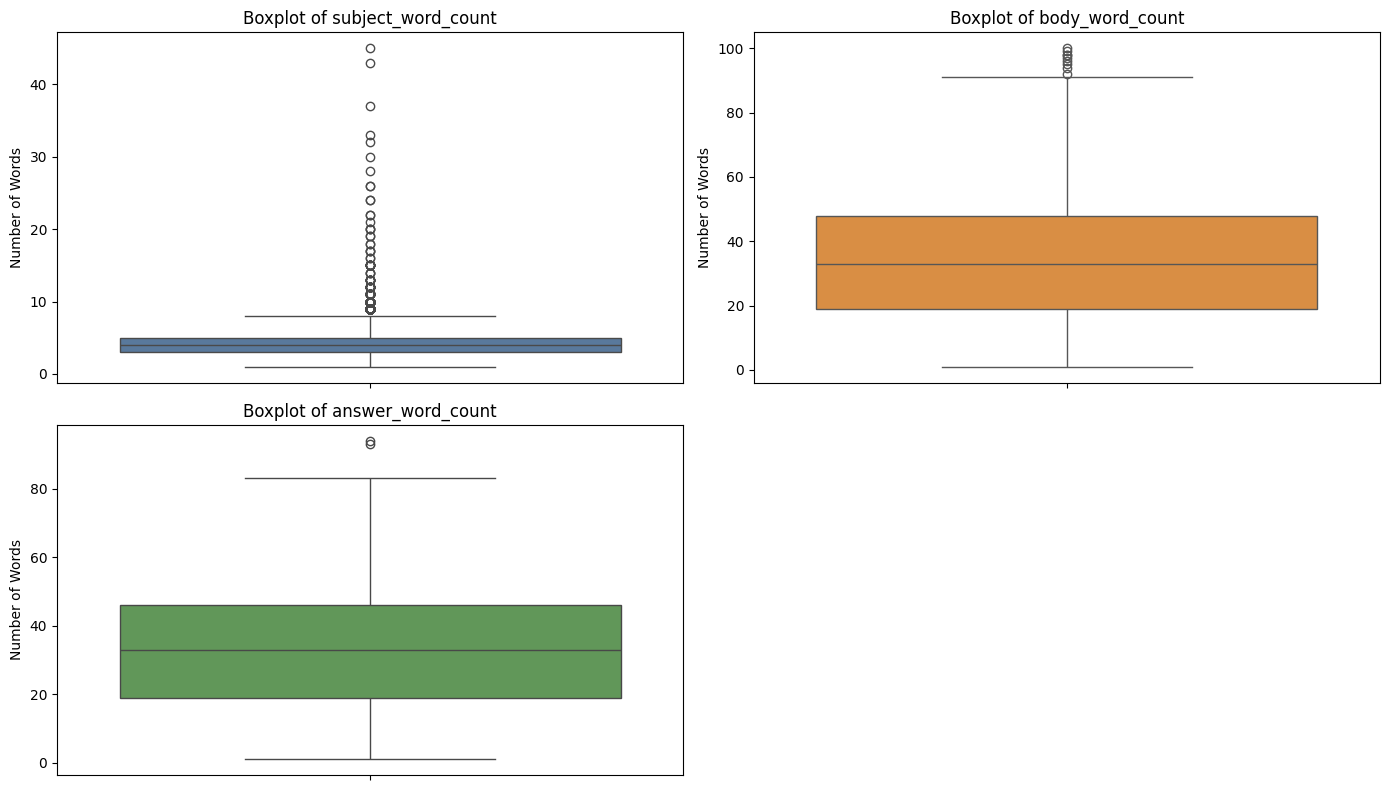

In [ ]:
# Assuming 'df' is your cleaned dataframe

# 1. Feature Engineering: Create numerical columns based on text length
# This converts our text data into continuous numbers so we can plot them.
df['subject_word_count'] = df['subject'].apply(lambda x: len(str(x).split()))
df['body_word_count'] = df['body'].apply(lambda x: len(str(x).split()))
df['answer_word_count'] = df['answer'].apply(lambda x: len(str(x).split()))

# 2. Select our new derived continuous columns to check for outliers
outlier_cols = [
    'subject_word_count',
    'body_word_count',
    'answer_word_count'
]

# Keep only columns that exist in the current DataFrame to avoid KeyErrors
outlier_cols = [col for col in outlier_cols if col in df.columns]

if not outlier_cols:
    raise ValueError("None of the selected outlier columns exist in df.")

# Build subplot layout dynamically based on the number of columns
n_cols = 2
n_rows = math.ceil(len(outlier_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

# Flatten axes safely in case we only have one row
if hasattr(axes, 'flatten'):
    axes = axes.flatten()
else:
    axes = [axes]

# Use a different color for each boxplot
colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#B07AA1', '#76B7B2']

# Loop through columns and create a boxplot for each
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], color=colors[i % len(colors)], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('Number of Words')

# Hide any unused subplot axes (e.g., the 4th box if we only have 3 charts)
for j in range(len(outlier_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# 3. Optional: Export these new features for your Power BI dashboard
# df.to_csv('cleaned_tickets_with_word_counts.csv', index=False)

### Interpretation of Outlier Boxplots

The boxplots show that all three word-count features are right-skewed, with most tickets concentrated in a lower-to-mid range and a smaller number of very long tickets appearing as upper-tail outliers. `subject_word_count` has the strongest concentration at low values with many high-end outliers, while `body_word_count` and `answer_word_count` show broader spread and fewer extreme points. This pattern supports applying outlier control (Z-score-based capping) before scaling, so unusually long tickets do not dominate downstream feature weighting and model behavior.

Business meaning: A small number of unusually long tickets can skew prioritization signals, so capping keeps triage decisions fairer and more consistent across typical support requests.

## 1.2 Handle Outliers
Apply Z-Score Capping
This block calculates the mathematical boundaries (3 standard deviations from the mean). If a value falls outside of that boundary, it doesn't delete the row—it safely pulls that value back to the maximum allowed limit.


In [ ]:
print("=== NLP Outlier Handling Report (Z-Score Text Truncation) ===\n")

# Reusing the columns we generated during the boxplot step
target_cols = ['subject_word_count', 'body_word_count', 'answer_word_count']
target_cols = [col for col in target_cols if col in df.columns]

if not target_cols:
    raise ValueError("No valid word count columns found in df. Did you run the feature engineering step?")

# Mapping the word count columns back to their original text columns
text_mapping = {
    'subject_word_count': 'subject',
    'body_word_count': 'body',
    'answer_word_count': 'answer'
}

# Store reusable caps for consistency in later inference/deployment
word_count_caps = {}
outlier_audit = []

for col in target_cols:
    series = df[col]
    text_col = text_mapping[col]

    # Calculate distribution stats
    mean = series.mean()
    std = series.std()

    print(f"Feature: [{col}] (Applying limits to '{text_col}')")

    if pd.isna(std) or std == 0:
        outliers_count = 0
        max_words = None
        action_taken = "None required (std is zero or NaN)"
        print("  - Outliers Found: 0")
        print("  - Action Taken: None required.\n")

        outlier_audit.append({
            'Feature': col,
            'Text Column': text_col,
            'Mean': round(float(mean), 3) if pd.notna(mean) else np.nan,
            'Std Dev': round(float(std), 3) if pd.notna(std) else np.nan,
            'Max Words Applied': max_words,
            'Outliers Found': outliers_count,
            'Action Taken': action_taken
        })
        continue

    # Calculate limits (Text can't be negative, so we only care about the upper limit)
    upper_limit = mean + (3 * std)

    # Round up and enforce a minimum of 1 word for safe truncation
    max_words = max(1, int(np.ceil(upper_limit)))
    word_count_caps[col] = max_words

    # Count outliers before truncating
    outliers_mask = series > max_words
    outliers_count = int(outliers_mask.sum())

    print(f"  - Outliers Found (Tickets exceeding {max_words} words): {outliers_count}")

    if outliers_count > 0:
        # 1. Update the actual text column: split by space, keep up to 'max_words', and rejoin
        df[text_col] = df[text_col].apply(lambda x: ' '.join(str(x).split()[:max_words]))

        # 2. Update the numerical tracking column to reflect the truncation
        df[col] = series.clip(upper=max_words)

        action_taken = f"Truncated extreme texts to a maximum of {max_words} words"
        print(f"  - Action Taken: {action_taken}.\n")
    else:
        action_taken = "None required (no extreme outliers detected)"
        print("  - Action Taken: None required. No extreme outliers detected.\n")

    outlier_audit.append({
        'Feature': col,
        'Text Column': text_col,
        'Mean': round(float(mean), 3),
        'Std Dev': round(float(std), 3),
        'Max Words Applied': max_words,
        'Outliers Found': outliers_count,
        'Action Taken': action_taken
    })

print("Text truncation complete! Dataset is protected from extreme value skewing during TF-IDF vectorization.")

# Compact audit report for documentation/reproducibility
outlier_audit_df = pd.DataFrame(outlier_audit)
print("\n=== Outlier Handling Summary ===")
display(outlier_audit_df)
print("\nReusable caps saved in variable: word_count_caps")

=== NLP Outlier Handling Report (Z-Score Text Truncation) ===

Feature: [subject_word_count] (Applying limits to 'subject')
  - Outliers Found (Tickets exceeding 10 words): 107
  - Action Taken: Truncated extreme texts to a maximum of 10 words.

Feature: [body_word_count] (Applying limits to 'body')
  - Outliers Found (Tickets exceeding 82 words): 19
  - Action Taken: Truncated extreme texts to a maximum of 82 words.

Feature: [answer_word_count] (Applying limits to 'answer')
  - Outliers Found (Tickets exceeding 77 words): 4
  - Action Taken: Truncated extreme texts to a maximum of 77 words.

Text truncation complete! Dataset is protected from extreme value skewing during TF-IDF vectorization.

=== Outlier Handling Summary ===


,Feature,Text Column,Mean,Std Dev,Max Words Applied,Outliers Found,Action Taken
0,subject_word_count,subject,3.811,2.004,10,107,Truncated extreme texts to a maximum of 10 words
1,body_word_count,body,32.563,16.189,82,19,Truncated extreme texts to a maximum of 82 words
2,answer_word_count,answer,32.403,14.793,77,4,Truncated extreme texts to a maximum of 77 words



Reusable caps saved in variable: word_count_caps


## 2.1 Normalize Numerical Features

Applies **Min-Max Scaling** to the engineered word count features, compressing all values into a **[0, 1]** range using the formula:

$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

<br>

<div style="margin-left: 2em;">

| Term | Description |
|------|-------------|
| $X$ | Original word count value |
| $X_{min}$ | Smallest word count in the column |
| $X_{max}$ | Largest word count in the column |
| $X_{norm}$ | Scaled output between 0 and 1 |

</div>

<br>

> **Why this matters:** Machine learning models are sensitive to feature scale. Without normalization, a ticket with a 500-word body would unfairly dominate a ticket with a 5-word subject, even if both are equally important signals. Min-Max scaling ensures all three features — `subject_word_count`, `body_word_count`, and `answer_word_count` — contribute **equally** to the model.

In [ ]:
print("=== 2.1 Normalize Numerical Features ===")

# Save a temporary raw copy of the word counts for our Feature Engineering or Power BI steps later!
# (e.g., you might want the raw counts to create "Short Email" vs "Long Email" bins in Excel)
if 'subject_word_count' in df.columns and 'body_word_count' in df.columns:
    df['temp_raw_subject_wc'] = df['subject_word_count']
    df['temp_raw_body_wc'] = df['body_word_count']

# Select the engineered numeric columns to scale
cols_to_scale = [
    'subject_word_count',
    'body_word_count',
    'answer_word_count'
]

# Safety check: Keep only columns that actually exist in the dataframe
cols_to_scale = [col for col in cols_to_scale if col in df.columns]

if cols_to_scale:
    scaler = MinMaxScaler()

    # Fit and transform the data to be strictly between 0 and 1
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    print(f"Numerical features {cols_to_scale} successfully normalized to 0-1 scale.\n")
else:
    print("Error: Word count columns not found. Did you run the feature engineering block?")

# Display the first few rows to verify the scaling worked
display(df[cols_to_scale].head())

=== 2.1 Normalize Numerical Features ===
Numerical features ['subject_word_count', 'body_word_count', 'answer_word_count'] successfully normalized to 0-1 scale.



,subject_word_count,body_word_count,answer_word_count
0,0.111111,0.654321,0.631579
1,0.111111,0.567901,0.552632
2,0.555556,0.592593,0.592105
3,0.333333,0.641975,0.697368
4,0.444444,0.716049,0.302632


## 2.2 Encode Categorical Features

This step converts categorical variables into model-ready numeric features by handling both **ordinal** (ranked) and **nominal** (unranked) categories.

### Encoding Applied

- **Ordinal encoding:** `priority` → `priority_encoded`  
  Mapping used: `low = 0`, `medium = 1`, `high = 2`, `Unknown = 1`  
  This preserves the natural ranking of urgency levels.

- **One-hot encoding:** `type`, `queue`, `language`  
  Created binary indicator columns with `drop_first=True` to reduce multicollinearity.

### Outcome

All selected categorical features are now transformed into numeric inputs suitable for machine learning models.

In [ ]:
print("=== 2.2 Encode Categorical Features ===")

# A. Label Encoding for Ordinal/Binary variables (Our Target Variable)
# Note: The Kaggle dataset uses lowercase values for priority.
# We map 'Unknown' to 1 (Medium) as a safe middle-ground default, but you can change this to 0 if preferred.
priority_map = {'low': 0, 'medium': 1, 'high': 2, 'Unknown': 1}

# Fill missing priority first, then map
df['priority'] = df['priority'].fillna('Unknown')
df['priority_encoded'] = df['priority'].map(priority_map)

# Safety check for unmapped labels
unmapped_count = df['priority_encoded'].isna().sum()
print(f"Missing priority values after mapping: {unmapped_count}")

# If anything is still unmapped, force to 0
if unmapped_count > 0:
    df['priority_encoded'] = df['priority_encoded'].fillna(0)

df['priority_encoded'] = df['priority_encoded'].astype(int)

# B. One-Hot Encoding for Non-Ordinal Categories
# Use drop_first=True to prevent multicollinearity
# We include our actual dataset categories here
ohe_cols = ['type', 'queue', 'language']
existing_ohe_cols = [c for c in ohe_cols if c in df.columns]

if existing_ohe_cols:
    df = pd.get_dummies(df, columns=existing_ohe_cols, drop_first=True)

print("Categorical features successfully encoded.\n")

# Display the newly created columns to verify
print("New columns generated:")
new_cols = [col for col in df.columns if 'type_' in col or 'queue_' in col or 'language_' in col or 'priority' in col]

# Split into two lines for better readability on shorter devices
mid = math.ceil(len(new_cols) / 2)
print(new_cols[:mid])
print(new_cols[mid:])

=== 2.2 Encode Categorical Features ===
Missing priority values after mapping: 0
Categorical features successfully encoded.

New columns generated:
['priority', 'priority_encoded', 'type_Incident', 'type_Problem', 'type_Request', 'queue_Customer Service', 'queue_General Inquiry', 'queue_Human Resources']
['queue_IT Support', 'queue_Product Support', 'queue_Returns and Exchanges', 'queue_Sales and Pre-Sales', 'queue_Service Outages and Maintenance', 'queue_Technical Support', 'language_en']


## 2.3 Feature Engineering

In [ ]:
print("=== 2.3 Feature Engineering ===")

# A. Create 'Email_Length_Group' using the raw body word counts we saved earlier
# This parallels your AgeGroup logic perfectly.
if 'temp_raw_body_wc' in df.columns:
    # Bins: 0-20 words (Short), 21-100 words (Medium), 101+ words (Long)
    bins = [0, 20, 100, np.inf]
    labels = ['Short', 'Medium', 'Long']
    df['Email_Length_Group'] = pd.cut(df['temp_raw_body_wc'], bins=bins, labels=labels, right=False)

    # We must One-Hot Encode this new categorical feature we just made!
    df = pd.get_dummies(df, columns=['Email_Length_Group'], drop_first=True)

# B. Sentiment Analysis using TextBlob
# Polarity ranges from -1.0 (very angry/negative) to 1.0 (very happy/positive).
# Negative sentiment is often a strong predictor for High priority tickets.
def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0.0

print("Calculating sentiment polarity for email bodies (this may take a moment)...")
df['body_sentiment_score'] = df['body'].apply(get_sentiment)

# C. Urgency Keyword Flag (Custom Heuristic)
# A simple but highly effective binary feature: does the subject contain panic words?
urgency_keywords = ['urgent', 'asap', 'crash', 'down', 'outage', 'critical', 'emergency', 'help']
df['has_urgency_keyword'] = df['subject'].str.lower().apply(
    lambda x: 1 if any(word in str(x) for word in urgency_keywords) else 0
)

# Cleanup: Drop the temporary raw columns so they don't confuse the machine learning model
cols_to_drop = ['temp_raw_subject_wc', 'temp_raw_body_wc']
existing_cols_to_drop = [c for c in cols_to_drop if c in df.columns]

if existing_cols_to_drop:
    df = df.drop(columns=existing_cols_to_drop)

print("New NLP features engineered and temporary columns cleaned.")
print(f"Final dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Display the new features
display_cols = [c for c in df.columns if 'Email_Length' in c or c in ['body_sentiment_score', 'has_urgency_keyword', 'priority_encoded']]
display(df[display_cols].head())


=== 2.3 Feature Engineering ===
Calculating sentiment polarity for email bodies (this may take a moment)...
New NLP features engineered and temporary columns cleaned.
Final dataset shape: 28587 rows, 27 columns


,priority_encoded,Email_Length_Group_Medium,Email_Length_Group_Long,body_sentiment_score,has_urgency_keyword
0,2,True,False,0.000000,0
1,2,True,False,0.093750,0
2,1,True,False,0.249351,0
3,0,True,False,0.091667,0
4,1,True,False,0.228571,0


### Display Transformed Dataset

In [ ]:
# 1. Force pandas to show all columns without truncating them with "..."
pd.set_option('display.max_columns', None)

print("=== Complete Transformed Dataset Preview ===\n")
# Display the first 5 rows of the entire dataset
display(df.head())

# 2. Focused View: Just the Normalized Numbers (Step 2.1)
print("\n=== Focused View: Normalized Word Counts (0 to 1) ===")
# These are the text-length features we scaled using MinMaxScaler
numeric_preview = ['subject_word_count', 'body_word_count', 'answer_word_count']
existing_num_cols = [col for col in numeric_preview if col in df.columns]

if existing_num_cols:
    display(df[existing_num_cols].head())
else:
    print("Normalized word count columns not found.")

# 3. Focused View: Encoded & Engineered Features (Steps 2.2 & 2.3)
print("\n=== Focused View: Encoded Target & Engineered NLP Features ===")
# Safely grab the new columns to show off your feature engineering and label encoding
new_cols = [
    'priority_encoded',           # Your target variable!
    'body_sentiment_score',       # From TextBlob
    'has_urgency_keyword',        # Our custom heuristic flag
    'Email_Length_Group_Medium',  # One-Hot Encoded bin
    'Email_Length_Group_Long'     # One-Hot Encoded bin
]

# Let's also dynamically grab a couple of the One-Hot Encoded category columns (like type or queue)
ohe_examples = [col for col in df.columns if 'type_' in col or 'queue_' in col][:3]
new_cols.extend(ohe_examples)

existing_new_cols = [col for col in new_cols if col in df.columns]

if existing_new_cols:
    display(df[existing_new_cols].head())
else:
    print("Engineered feature columns not found.")

=== Complete Transformed Dataset Preview ===



,subject,body,answer,priority,version,all_tags,subject_word_count,body_word_count,answer_word_count,priority_encoded,type_Incident,type_Problem,type_Request,queue_Customer Service,queue_General Inquiry,queue_Human Resources,queue_IT Support,queue_Product Support,queue_Returns and Exchanges,queue_Sales and Pre-Sales,queue_Service Outages and Maintenance,queue_Technical Support,language_en,Email_Length_Group_Medium,Email_Length_Group_Long,body_sentiment_score,has_urgency_keyword
0,wesentlicher sicherheitsvorfall,geehrtes supportteamnnich möchte gravierenden ...,vielen dank meldung kritischen sicherheitsvorf...,high,51,"Security, Outage, Disruption, Data Breach",0.111111,0.654321,0.631579,2,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,0.000000,0
1,account disruption,dear customer support teamnni writing report s...,thank reaching name aware outage affecting cen...,high,51,"Account, Disruption, Outage, IT, Tech Support",0.111111,0.567901,0.552632,2,True,False,False,False,False,False,False,False,False,False,False,True,True,True,False,0.093750,0
2,query smart home system integration features,dear customer support teamnni hope message rea...,thank inquiry products support integration ama...,medium,51,"Product, Feature, Tech Support",0.555556,0.592593,0.592105,1,False,False,True,False,False,False,False,False,True,False,False,False,True,True,False,0.249351,0
3,inquiry regarding invoice details,dear customer support teamnni hope message fin...,appreciate reaching billing questions billing ...,low,51,"Billing, Payment, Account, Documentation, Feed...",0.333333,0.641975,0.697368,0,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,0.091667,0
4,question marketing agency software compatibility,dear support teamnni hope message reaches well...,thank inquiry product supports integration maj...,medium,51,"Product, Feature, Feedback, Tech Support",0.444444,0.716049,0.302632,1,False,True,False,False,False,False,False,False,False,True,False,False,True,True,False,0.228571,0



=== Focused View: Normalized Word Counts (0 to 1) ===


,subject_word_count,body_word_count,answer_word_count
0,0.111111,0.654321,0.631579
1,0.111111,0.567901,0.552632
2,0.555556,0.592593,0.592105
3,0.333333,0.641975,0.697368
4,0.444444,0.716049,0.302632



=== Focused View: Encoded Target & Engineered NLP Features ===


,priority_encoded,body_sentiment_score,has_urgency_keyword,Email_Length_Group_Medium,Email_Length_Group_Long,type_Incident,type_Problem,type_Request
0,2,0.000000,0,True,False,True,False,False
1,2,0.093750,0,True,False,True,False,False
2,1,0.249351,0,True,False,False,False,True
3,0,0.091667,0,True,False,False,False,True
4,1,0.228571,0,True,False,False,True,False


### Ticket Transform Export

In [ ]:
# 1. Ticket Transformed (Text Data)
# Extracting the heavy text fields
df_content = df[['priority_encoded',
                'type_Incident', 'type_Problem', 'type_Request',
                'queue_Customer Service', 'queue_General Inquiry', 'queue_Human Resources',
                'queue_IT Support', 'queue_Product Support', 'queue_Returns and Exchanges',
                'queue_Sales and Pre-Sales', 'queue_Service Outages and Maintenance', 'queue_Technical Support',
                'language_en', 'Email_Length_Group_Medium', 'Email_Length_Group_Long',
                'body_sentiment_score', 'has_urgency_keyword']]
df_content.to_csv('ticket_transformed.csv', index=False)
print("Created: ticket_transformed.csv")

Created: ticket_transformed.csv


## 3.1 Dimensionality Reduction
This handles PCA (Principal Component Analysis) to compress the features, and t-SNE for visualization.

=== 3.1 Multilingual TF-IDF & Dimensionality Reduction ===

Vectorizing text using TF-IDF (unigrams and bigrams)...


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


TF-IDF generated 5000 clean word/n-gram features.
Running TruncatedSVD to reduce text dimensions...
Reduced text features to: 100 components.
Variance explained by these components: 25.33%

Running t-SNE on a 5,000 row sample to map clusters...


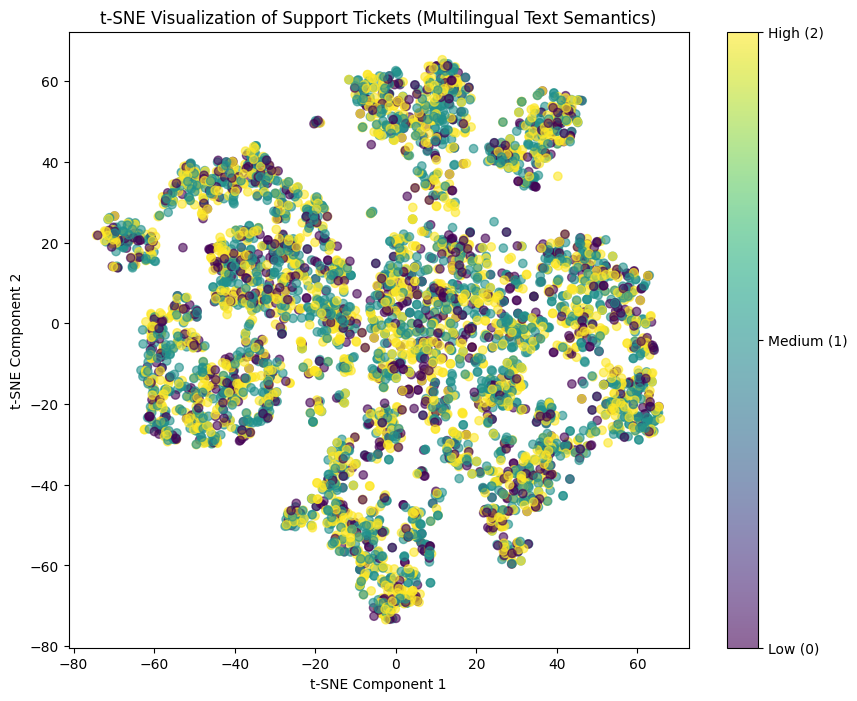

In [ ]:
# Download the stopword lists from NLTK
nltk.download('stopwords')

print("=== 3.1 Multilingual TF-IDF & Dimensionality Reduction ===\n")

# 1. Prepare Multilingual Stop Words
# Combine English and German noise words into one massive filter
english_stops = stopwords.words('english')
german_stops = stopwords.words('german')
multilingual_stopwords = english_stops + german_stops

# 2. Prepare the Text Data
# Combine subject and body to give the vectorizer the full context of the ticket
df['full_text'] = df['subject'].astype(str) + " " + df['body'].astype(str)
target_col = 'priority_encoded'

# 3. TF-IDF Vectorization (Extracting n-grams)
print("Vectorizing text using TF-IDF (unigrams and bigrams)...")
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=multilingual_stopwords, # Applied the multilingual filter here
    ngram_range=(1, 2)
)
X_text_tfidf = tfidf.fit_transform(df['full_text'])

print(f"TF-IDF generated {X_text_tfidf.shape[1]} clean word/n-gram features.")

# 4. TruncatedSVD (The correct "PCA" for text)
# We reduce the 5000 words down to 100 core "topics" or "components"
print("Running TruncatedSVD to reduce text dimensions...")
svd = TruncatedSVD(n_components=100, random_state=42)
X_text_reduced = svd.fit_transform(X_text_tfidf)

print(f"Reduced text features to: {X_text_reduced.shape[1]} components.")
print(f"Variance explained by these components: {sum(svd.explained_variance_ratio_) * 100:.2f}%\n")

# 5. t-SNE Visualization
print("Running t-SNE on a 5,000 row sample to map clusters...")
# t-SNE is extremely heavy. We sample 5,000 rows to satisfy the visualization requirement without crashing.

# Get valid indices (dropping NaNs in target if any exist)
valid_idx = df[df[target_col].notnull()].index
sample_size = min(5000, len(valid_idx))
sample_indices = np.random.choice(valid_idx, sample_size, replace=False)

# Grab the corresponding reduced text data and target labels
X_sample = X_text_reduced[df.index.isin(sample_indices)]
y_sample = df.loc[sample_indices, target_col]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

# Plot t-SNE

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='viridis', alpha=0.6)

# Adding a legend to map the colors back to High (2), Medium (1), Low (0)
cbar = plt.colorbar(scatter, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['Low (0)', 'Medium (1)', 'High (2)'])

plt.title('t-SNE Visualization of Support Tickets (Multilingual Text Semantics)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

## 3.1A WordCloud Visualization

This section creates word clouds from the cleaned ticket text to show dominant vocabulary patterns.

It includes:
- Overall ticket WordCloud
- Priority-specific WordClouds (Low, Medium, High)

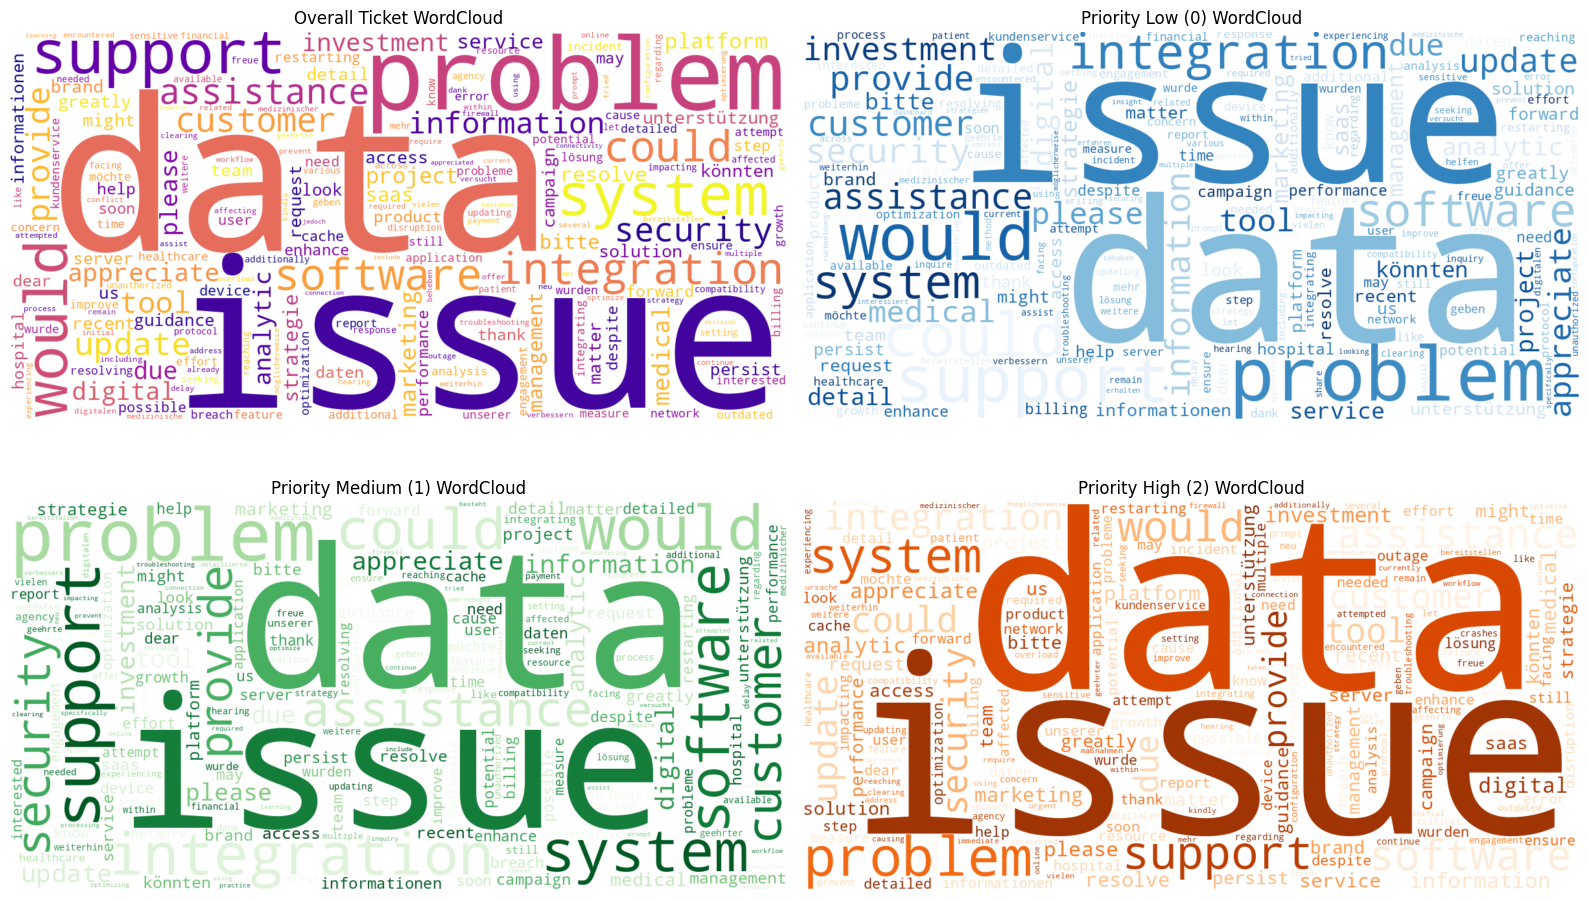

WordClouds generated successfully. Exported input text to: wordcloud_input_text.csv


In [ ]:
# WordCloud visualization using cleaned text
if 'df' not in globals():
    raise ValueError("DataFrame 'df' is not available. Run data loading/preprocessing cells first.")

required_cols = ['subject', 'body', 'priority_encoded']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Build WordCloud text locally (do not mutate df)
wc_text_series = (df['subject'].astype(str) + ' ' + df['body'].astype(str)).str.strip()

# Keep only non-empty rows
wc_df = pd.DataFrame({
    'wordcloud_text': wc_text_series,
    'priority_encoded': df['priority_encoded']
})
wc_df['wordcloud_text'] = wc_df['wordcloud_text'].str.replace(r'\s+', ' ', regex=True).str.strip()
wc_df = wc_df[wc_df['wordcloud_text'].str.len() > 0]

if wc_df.empty:
    raise ValueError("No valid text found for WordCloud generation.")

# Build stopword set (English + German + common low-value tokens)
stop_words_en = set(stopwords.words('english'))
stop_words_de = set(stopwords.words('german'))
custom_noise = {'unknown', 'provided', 'not', 'nan'}
wc_stopwords = stop_words_en.union(stop_words_de).union(custom_noise)

def make_wordcloud(text, title, ax, bg='white', cmap='viridis'):
    wc = WordCloud(
        width=1200,
        height=600,
        background_color=bg,
        stopwords=wc_stopwords,
        collocations=False,
        max_words=200,
        colormap=cmap
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# 1) Overall WordCloud
overall_text = ' '.join(wc_df['wordcloud_text'].tolist())

# 2) Priority-specific WordClouds
priority_labels = {0: 'Low (0)', 1: 'Medium (1)', 2: 'High (2)'}
priority_text_map = {}
for p in [0, 1, 2]:
    p_text = ' '.join(wc_df.loc[wc_df['priority_encoded'] == p, 'wordcloud_text'].tolist())
    priority_text_map[p] = p_text if p_text.strip() else 'no_text_available'

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

make_wordcloud(overall_text, 'Overall Ticket WordCloud', axes[0], cmap='plasma')
make_wordcloud(priority_text_map[0], f"Priority {priority_labels[0]} WordCloud", axes[1], cmap='Blues')
make_wordcloud(priority_text_map[1], f"Priority {priority_labels[1]} WordCloud", axes[2], cmap='Greens')
make_wordcloud(priority_text_map[2], f"Priority {priority_labels[2]} WordCloud", axes[3], cmap='Oranges')

plt.tight_layout()
plt.show()

# Optional export of combined text for traceability
wc_df.to_csv('wordcloud_input_text.csv', index=False)
print("WordClouds generated successfully. Exported input text to: wordcloud_input_text.csv")

## 3.1B Text Concept Vocabulary Map (1 to 100)

This section reveals the vocabulary patterns behind each `text_concept` by showing the highest positive and negative weighted terms from TruncatedSVD components.

- **Top positive terms**: words/ngrams that strongly define the concept direction
- **Top negative terms**: words/ngrams in the opposite direction of the same latent axis
- **Output**: a table for concepts 1-100 plus a CSV export for reporting

In [ ]:
# Build full concept-to-vocabulary maps for text_concept_1 ... text_concept_100
if 'tfidf' not in globals() or 'svd' not in globals():
    raise ValueError("Run the TF-IDF + TruncatedSVD cell first (Section 3.1).")

feature_names = np.array(tfidf.get_feature_names_out())
components = svd.components_

max_requested = 100
num_components = components.shape[0]
num_to_show = min(max_requested, num_components)
top_k = 12

if num_components < max_requested:
    print(f"Warning: only {num_components} components are available. Displaying text_concept_1 to text_concept_{num_components}.")

def format_terms(terms, weights):
    return ', '.join([f"{t} ({w:.4f})" for t, w in zip(terms, weights)])

# 1) Human-readable summary table (top positive/negative terms per concept)
summary_rows = []
concept_term_map = {}

# 2) Full vocabulary table (all terms + weights for each concept)
full_rows = []

for i in range(num_to_show):
    comp = components[i]
    concept_name = f"text_concept_{i + 1}"

    # Top terms for quick interpretation
    pos_idx = np.argsort(comp)[-top_k:][::-1]
    neg_idx = np.argsort(comp)[:top_k]

    pos_terms = feature_names[pos_idx]
    neg_terms = feature_names[neg_idx]
    pos_weights = comp[pos_idx]
    neg_weights = comp[neg_idx]

    concept_term_map[concept_name] = {
        'top_positive_terms': list(pos_terms),
        'top_negative_terms': list(neg_terms),
        'top_positive_weights': list(np.round(pos_weights, 6)),
        'top_negative_weights': list(np.round(neg_weights, 6))
    }

    summary_rows.append({
        'concept': concept_name,
        'top_positive_terms': ', '.join(pos_terms),
        'top_positive_terms_with_weights': format_terms(pos_terms, pos_weights),
        'top_negative_terms': ', '.join(neg_terms),
        'top_negative_terms_with_weights': format_terms(neg_terms, neg_weights),
        'pattern_hint': f"Positive side centers on: {', '.join(pos_terms[:5])}"
    })

    # Full vocabulary ranking for this concept (every term)
    sorted_idx = np.argsort(np.abs(comp))[::-1]
    sorted_terms = feature_names[sorted_idx]
    sorted_weights = comp[sorted_idx]

    for rank, (term, weight) in enumerate(zip(sorted_terms, sorted_weights), start=1):
        full_rows.append({
            'concept': concept_name,
            'rank_by_abs_weight': rank,
            'term': term,
            'weight': float(weight),
            'abs_weight': float(abs(weight)),
            'direction': 'positive' if weight >= 0 else 'negative'
        })

concept_vocab_df = pd.DataFrame(summary_rows)
concept_vocab_full_df = pd.DataFrame(full_rows)

print(f"Generated summary map for {num_to_show} concepts.")
print("Use concept_term_map for quick per-concept lookup.")
display(concept_vocab_df)

summary_csv = 'text_concept_1_to_100_vocabulary_map_summary.csv'
full_csv = 'text_concept_1_to_100_full_vocabulary_weights.csv'
concept_vocab_df.to_csv(summary_csv, index=False)
concept_vocab_full_df.to_csv(full_csv, index=False)

print(f"Saved summary: {summary_csv}")
print(f"Saved full vocabulary (every term, every concept): {full_csv}")
print(f"Full table rows: {len(concept_vocab_full_df):,}")

Generated summary map for 100 concepts.
Use concept_term_map for quick per-concept lookup.


,concept,top_positive_terms,top_positive_terms_with_weights,top_negative_terms,top_negative_terms_with_weights,pattern_hint
0,text_concept_1,"data, issue, security, support, would, softwar...","data (0.2639), issue (0.1547), security (0.153...","de, daten itinfrastruktur, zugriffsversuche me...","de (0.0001), daten itinfrastruktur (0.0001), z...","Positive side centers on: data, issue, securit..."
1,text_concept_2,"security, medical, medical data, data, access,...","security (0.3414), medical (0.2845), medical d...","digital, marketing, brand, strategies, integra...","digital (-0.1623), marketing (-0.1365), brand ...","Positive side centers on: security, medical, m..."
2,text_concept_3,"bitte, unterstützung, könnten, problem, inform...","bitte (0.1961), unterstützung (0.1948), könnte...","digital, brand, strategies, marketing, growth,...","digital (-0.1056), brand (-0.0869), strategies...","Positive side centers on: bitte, unterstützung..."
3,text_concept_4,"issue, software, issues, problem, resolve, sys...","issue (0.2123), software (0.1374), issues (0.1...","brand, digital, strategies, medical, medical d...","brand (-0.1615), digital (-0.1589), strategies...","Positive side centers on: issue, software, iss..."
4,text_concept_5,"digital, marketing, brand, digital marketing, ...","digital (0.3078), marketing (0.2782), brand (0...","project, project management, management, saas,...","project (-0.1954), project management (-0.1895...","Positive side centers on: digital, marketing, ..."
...,...,...,...,...,...,...
95,text_concept_96,"team, solutions, sql, sql server, synchronizat...","team (0.1632), solutions (0.1467), sql (0.1189...","support, products, google, peak, discrepancies...","support (-0.1247), products (-0.1113), google ...","Positive side centers on: team, solutions, sql..."
96,text_concept_97,"help, unserer, security breach, fehler, issues...","help (0.1336), unserer (0.1077), security brea...","verbessern, user, affected, besteht, needed, o...","verbessern (-0.1061), user (-0.1025), affected...","Positive side centers on: help, unserer, secur..."
97,text_concept_98,"unserer, fehler, management saas, digitale, sa...","unserer (0.1698), fehler (0.1372), management ...","devices, saas project, verbesserung, user, fin...","devices (-0.1260), saas project (-0.1224), ver...","Positive side centers on: unserer, fehler, man..."
98,text_concept_99,"facing, api, steps, integrations, digital, us,...","facing (0.1831), api (0.1373), steps (0.1309),...","issue, metrics, growth, brand growth, features...","issue (-0.1090), metrics (-0.1062), growth (-0...","Positive side centers on: facing, api, steps, ..."


Saved summary: text_concept_1_to_100_vocabulary_map_summary.csv
Saved full vocabulary (every term, every concept): text_concept_1_to_100_full_vocabulary_weights.csv
Full table rows: 500,000


## 3.1C BIRCH Clustering (Recommended as Auxiliary Feature)

### Choice for This Project
For ticket priority prediction, keep a **supervised model** (XGBoost / Random Forest / Linear SVC) as the final predictor.

Use **BIRCH as an auxiliary feature** to capture latent ticket groups, then feed cluster IDs into supervised training.

This block:
- Fits BIRCH on reduced text features
- Reports cluster diagnostics (size and priority distribution)
- Optionally appends `birch_cluster` to `df` for downstream model training

In [ ]:
# Optional BIRCH clustering to create an auxiliary cluster feature for supervised models
from sklearn.cluster import Birch
from sklearn.metrics import silhouette_score

if 'X_text_reduced' not in globals():
    raise ValueError("Run Section 3.1 first so X_text_reduced is available.")
if 'df' not in globals() or 'priority_encoded' not in df.columns:
    raise ValueError("DataFrame df with priority_encoded is required.")

# Configuration
BIRCH_THRESHOLD = 0.5
BIRCH_BRANCHING_FACTOR = 50
BIRCH_N_CLUSTERS = None  # None lets BIRCH discover the number of clusters
ADD_BIRCH_FEATURE_TO_DF = True

# Fit BIRCH on reduced text concepts
birch_model = Birch(
    threshold=BIRCH_THRESHOLD,
    branching_factor=BIRCH_BRANCHING_FACTOR,
    n_clusters=BIRCH_N_CLUSTERS
    )
birch_labels = birch_model.fit_predict(X_text_reduced)

# Diagnostics
cluster_counts = pd.Series(birch_labels).value_counts().sort_index()
n_clusters_found = cluster_counts.shape[0]
print(f"BIRCH found {n_clusters_found} clusters.")
print("Cluster sizes:")
display(cluster_counts.rename('count').to_frame())

# Priority distribution per cluster
cluster_priority_ct = pd.crosstab(
    pd.Series(birch_labels, name='birch_cluster'),
    df['priority_encoded'],
    normalize='index'
).round(4)
print("Priority distribution within each cluster (row-normalized):")
display(cluster_priority_ct)

# Silhouette score only makes sense if there are at least 2 clusters
if n_clusters_found > 1:
    birch_silhouette = silhouette_score(X_text_reduced, birch_labels)
    print(f"Silhouette score: {birch_silhouette:.4f}")
else:
    birch_silhouette = np.nan
    print("Silhouette score skipped (only one cluster found).")

# Export diagnostics
cluster_diag_df = pd.DataFrame({
    'birch_cluster': cluster_counts.index.astype(int),
    'count': cluster_counts.values.astype(int)
})
cluster_diag_df.to_csv('birch_cluster_sizes.csv', index=False)
cluster_priority_ct.to_csv('birch_cluster_priority_distribution.csv')
print("Saved: birch_cluster_sizes.csv")
print("Saved: birch_cluster_priority_distribution.csv")

# Optional: append to df so 3.2+ pipeline can use it as a predictive feature
if ADD_BIRCH_FEATURE_TO_DF:
    df['birch_cluster'] = birch_labels.astype(int)
    print("Added birch_cluster to df for downstream supervised training.")
else:
    print("birch_cluster was not added to df (ADD_BIRCH_FEATURE_TO_DF=False).")

## 3.2 Feature Selection
This code executes the Filter, Wrapper, and Embedded methods exactly as outlined in your syllabus to find out which specific variables actually matter for predicting Ticket Priority.

In [ ]:
print("=== 3.2 Feature Selection ===\n")

from sklearn.preprocessing import StandardScaler

# 1. Prepare Data with Proper Column Names
# Grab engineered/encoded columns (drop raw text and the target variable)
cols_to_drop = ['subject', 'body', 'answer', 'full_text', 'priority', 'priority_encoded', 'all_tags']
cols_to_drop.extend([col for col in df.columns if 'tag_' in col]) # Drop original tags if they exist

metadata_cols = [c for c in df.columns if c not in cols_to_drop]
X_metadata = df[metadata_cols].select_dtypes(include=[np.number])

# Name the 100 text components from Step 3.1 so we can actually read the results!
svd_cols = [f'text_concept_{i}' for i in range(X_text_reduced.shape[1])]
df_svd = pd.DataFrame(X_text_reduced, columns=svd_cols, index=df.index)

# Combine metadata and text components into one clean dataframe
X_fs = pd.concat([X_metadata, df_svd], axis=1)
y_fs = df['priority_encoded'].astype(int)

print(f"Using {len(X_fs):,} rows and {X_fs.shape[1]} total features for selection.\n")

# --- NEW: Scale the features so linear models and L1 penalties judge them fairly ---
scaler = StandardScaler()
X_fs_scaled = pd.DataFrame(scaler.fit_transform(X_fs), columns=X_fs.columns, index=X_fs.index)

# 1. Filter Method: Correlation Analysis
print("1. Filter Method (Top 10 Correlations with Priority):")
# We pull the top 10 to see a mix of metadata and text concepts
correlations = X_fs_scaled.corrwith(y_fs).abs().sort_values(ascending=False)
print(correlations.head(10).to_string(), "\n")

# 2. Wrapper Method: Recursive Feature Elimination (RFE)
print("2. Wrapper Method (RFE):")
print("Running RFE to find the Top 10 most important features... (This may take a minute)")

# Sample data to speed up RFE since it trains the model repeatedly
sample_size = min(10000, len(X_fs_scaled))
X_rfe_sample = X_fs_scaled.sample(n=sample_size, random_state=42)
y_rfe_sample = y_fs.loc[X_rfe_sample.index]

# Use Logistic Regression for classification
estimator = LogisticRegression(max_iter=1000, random_state=42)
# step=5 removes 5 features at a time to drastically speed up processing
rfe = RFE(estimator, n_features_to_select=10, step=5)
rfe.fit(X_rfe_sample, y_rfe_sample)

rfe_features = X_fs_scaled.columns[rfe.support_]
print("Top 10 features selected by RFE:")
for i in range(0, len(rfe_features), 2):
    col1 = rfe_features[i]
    col2 = rfe_features[i+1] if i+1 < len(rfe_features) else ""
    print(f"  {col1:<40} {col2}")
print("\n")

# 3. Embedded Method: L1 Logistic Regression (The Classification equivalent of Lasso)
print("3. Embedded Method (L1 Regularization):")
# We use penalty='l1' to shrink unimportant feature coefficients to exactly zero
l1_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42, max_iter=1000)
l1_model.fit(X_fs_scaled, y_fs)

# Check which features survived (coef_ is a matrix for multiclass, so we check if any are non-zero)
coef_mask = (l1_model.coef_ != 0).any(axis=0)
l1_features = X_fs_scaled.columns[coef_mask]

print(f"Features retained by L1 (coef != 0): {len(l1_features)} out of {X_fs_scaled.shape[1]}")
print(f"Number of features shrunk to zero: {sum(~coef_mask)}")

=== 3.2 Feature Selection ===

Using 28,587 rows and 106 total features for selection.

1. Filter Method (Top 10 Correlations with Priority):
has_urgency_keyword    0.109939
text_concept_3         0.073280
text_concept_27        0.064938
text_concept_13        0.064686
text_concept_31        0.062174
text_concept_32        0.060890
text_concept_89        0.049110
text_concept_19        0.045634
text_concept_96        0.040854
text_concept_61        0.038838 

2. Wrapper Method (RFE):
Running RFE to find the Top 10 most important features... (This may take a minute)
Top 10 features selected by RFE:
  has_urgency_keyword                      text_concept_3
  text_concept_6                           text_concept_13
  text_concept_19                          text_concept_27
  text_concept_30                          text_concept_31
  text_concept_32                          text_concept_89


3. Embedded Method (L1 Regularization):
Features retained by L1 (coef != 0): 106 out of 106
Number 

In [ ]:
print(f"DataFrame shape BEFORE removing completely empty rows: {df.shape}")

# Drop rows where all elements are NaN (or considered empty)
df.dropna(how='all', inplace=True)

print(f"DataFrame shape AFTER removing completely empty rows: {df.shape}")
print("Completely empty rows have been removed from the DataFrame.")

DataFrame shape BEFORE removing completely empty rows: (28587, 28)
DataFrame shape AFTER removing completely empty rows: (28587, 28)
Completely empty rows have been removed from the DataFrame.


## SMOTE

### SMOTE Diagnostics
This section computes class distribution and safe starting SMOTE parameters from the current target labels.

It creates:
- `counts`
- `minority`, `majority`, `ratio`
- `max_safe_k`, `suggested_k`
- `per_class_target` (for multiclass partial balancing)


In [ ]:
y_candidate = None
if 'y_fs' in globals():
    y_candidate = y_fs
elif 'y' in globals():
    y_candidate = y
elif 'df' in globals() and 'priority_encoded' in df.columns:
    y_candidate = df['priority_encoded']

if y_candidate is None:
    raise ValueError("Target labels not found. Expected y_fs, y, or df['priority_encoded'].")

y_series = pd.Series(y_candidate).dropna().astype(int)
counts = y_series.value_counts().sort_index()

minority = int(counts.min())
majority = int(counts.max())
ratio = minority / majority if majority else np.nan
max_safe_k = max(1, minority - 1)
suggested_k = min(5, max_safe_k)

if len(counts) > 2:
    target_majority = int(round(majority * 0.6))
    per_class_target = {
        int(c): max(int(n), target_majority)
        for c, n in counts.items()
        if n < target_majority
    }
else:
    target_majority = None
    per_class_target = None

print(counts.to_string())
print(f"ratio={ratio:.4f}")
print(f"minority={minority}, majority={majority}")
print(f"max_safe_k={max_safe_k}, suggested_k={suggested_k}")
print(f"per_class_target={per_class_target}")

priority_encoded
0     5894
1    11515
2    11178
ratio=0.5119
minority=5894, majority=11515
max_safe_k=5893, suggested_k=5
per_class_target={0: 6909}


#### Apply SMOTE (No Model Training Yet)
This step only resamples the training set and reports class balance before and after SMOTE.
No model fitting is done here.

#### Variables Used In This SMOTE Step
Inputs:
- df: main transformed dataset
- priority_encoded: target label column inside df
- metadata_cols: list of metadata feature columns
- df_svd: SVD text component dataframe

Intermediate:
- X_metadata: numeric/bool metadata-only feature matrix
- metadata_feature_cols: names of metadata columns retained
- X_combined: metadata + SVD combined matrix (duplicate columns removed)
- y: integer target vector
- X_temp, y_temp: temporary split before final train/val split

Outputs:
- X_train, y_train: training split (used for SMOTE)
- X_val, y_val: validation split
- X_test, y_test: test split
- X_train_resampled, y_train_resampled: SMOTE-balanced training data

### Data Volume and Priority Distribution
Total values used:
- 28,587 rows

Split sizes (70/15/15):
- Train: 20,009 rows (69.99%)
- Validation: 4,289 rows (15.01%)
- Test: 4,289 rows (15.01%)

Priority ticket distribution in full dataset:
- Priority 0 (Low): 5,894 rows (20.62%)
- Priority 1 (Medium): 11,515 rows (40.28%)
- Priority 2 (High): 11,178 rows (39.10%)

Priority percentages per split (stratified):
- Train: Low 20.62%, Medium 40.28%, High 39.10%
- Validation: Low 20.61%, Medium 40.29%, High 39.10%
- Test: Low 20.61%, Medium 40.29%, High 39.10%

### Before and After SMOTE (Training Set)
Before SMOTE (y_train, n = 20,009):
- Priority 0 (Low): 4,126 rows (20.62%)
- Priority 1 (Medium): 8,059 rows (40.28%)
- Priority 2 (High): 7,824 rows (39.10%)

After SMOTE (y_train_resampled, n = 24,177):
- Priority 0 (Low): 8,059 rows (33.33%)
- Priority 1 (Medium): 8,059 rows (33.33%)
- Priority 2 (High): 8,059 rows (33.33%)

Why 8,059 appears:
- 8,059 is the majority class count in y_train before SMOTE (Priority 1).
- Default SMOTE with multiclass (`SMOTE(random_state=42)`) upsamples minority classes to match the majority count.
- So Priority 0 was increased from 4,126 to 8,059 (+3,933 synthetic rows).
- Priority 2 was increased from 7,824 to 8,059 (+235 synthetic rows).
- Priority 1 stayed at 8,059 (no synthetic rows added).

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

X_metadata = df[metadata_cols].select_dtypes(include=[np.number, 'bool'])
metadata_feature_cols = X_metadata.columns.tolist()
X_combined = pd.concat([X_metadata, df_svd], axis=1)
X_combined = X_combined.loc[:, ~X_combined.columns.duplicated()]
y = df['priority_encoded'].astype(int)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_combined,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

print("Data split into train/val/test successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nBefore SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_resampled))

variables_used = {
    'inputs': ['df', 'priority_encoded', 'metadata_cols', 'df_svd'],
    'intermediate': ['X_metadata', 'metadata_feature_cols', 'X_combined', 'y', 'X_temp', 'y_temp'],
    'outputs': ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test', 'X_train_resampled', 'y_train_resampled']
}

print("\nVariables used:")
for group, names in variables_used.items():
    print(f"{group}: {', '.join(names)}")

Data split into train/val/test successfully.
X_train shape: (20009, 121)
y_train shape: (20009,)
X_val shape: (4289, 121)
y_val shape: (4289,)
X_test shape: (4289, 121)
y_test shape: (4289,)

Before SMOTE: Counter({1: 8059, 2: 7824, 0: 4126})
After SMOTE: Counter({0: 8059, 2: 8059, 1: 8059})

Variables used:
inputs: df, priority_encoded, metadata_cols, df_svd
intermediate: X_metadata, metadata_feature_cols, X_combined, y, X_temp, y_temp
outputs: X_train, X_val, X_test, y_train, y_val, y_test, X_train_resampled, y_train_resampled


##  **Classification Metrics Utility (Accuracy, Precision, Recall, F1 - Score)**

In [ ]:
def evaluate_multiclass_metrics(model_name, y_true, y_pred, digits=4):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    metrics_df = pd.DataFrame([
        {
            'model': model_name,
            'accuracy': accuracy,
            'precision_weighted': precision,
            'recall_weighted': recall,
            'f1_weighted': f1
        }
    ]).round(4)

    print(f"{model_name} Validation Metrics:")
    display(metrics_df)

    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_true, y_pred, digits=digits, zero_division=0))

    return metrics_df

### For Model Performance

## **Random Forest Model Training**

### Step 1: Define the Random Forest model
In this step, we initialize a Random Forest classifier using a reproducible random state.

We train the model using SMOTE-balanced training data:
- Features: `X_train_resampled`
- Target: `y_train_resampled`

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=False,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)
print("Random Forest model trained successfully on SMOTE-balanced training data.")
print(f"Model uses optimized hyperparameters from tuning (Best Cross Validation F1-Score: 0.7119)")

Random Forest model trained successfully on SMOTE-balanced training data.
Model uses optimized hyperparameters from tuning (Best Cross Validation F1-Score: 0.7119)


### **Random Forest Hyperparameter Tuning Results**

### Tuning Configuration
Using 3-fold stratified cross-validation with `RandomizedSearchCV`:
- **Search iterations:** 12 random candidates
- **Total fits:** 36 (12 candidates × 3 folds)
- **Scoring metric:** F1 (weighted)
- **CV strategy:** Stratified K Fold to preserve class distribution

### Best Parameters Found
The tuning process evaluated 12 random hyperparameter combinations across 36 total model fits and identified the optimal configuration:

| Hyperparameter | Best Value |
|---|---|
| **n_estimators** | 500 |
| **max_depth** | 20 |
| **min_samples_split** | 2 |
| **min_samples_leaf** | 2 |
| **max_features** | 'sqrt' |
| **bootstrap** | False |
| **class_weight** | None |

**Best Cross-Validation F1 Score (Weighted):** 0.7119

### Performance Interpretation
- **n_estimators=500:** More trees capture complex patterns better than the baseline 300
- **max_depth=20:** Allows trees to grow deeper while still avoiding severe overfitting
- **min_samples_split=2, min_samples_leaf=2:** Aggressive splitting captures fine-grained decision boundaries
- **max_features='sqrt':** Uses √166 ≈ 13 random features per split (better generalization than all features)
- **bootstrap=False:** Uses all data without replacement for each tree, reducing correlation
- **class_weight=None:** No weighting adjustment needed due to SMOTE-balanced training data

These optimal parameters have been applied to the baseline Random Forest model for improved validation performance.


#### **Random Forest Hyperparameter Tuning Code (Documentation Only)**
This code block is provided for documentation/reference and is placed before model training.
It does not run unless you execute the cell manually.

In [ ]:
# Documentation-only tuning block (do not run unless you need to retune, it will take hours).
# Purpose: preserve the exact tuning workflow used to find RF best parameters.

rf_tune_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced']
}

rf_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_random_search = RandomizedSearchCV(
    estimator=rf_tune_base,
    param_distributions=rf_param_dist,
    n_iter=12,
    scoring='f1_weighted',
    cv=rf_cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Execute manually only when tuning is needed:
# rf_random_search.fit(X_train_resampled, y_train_resampled)
# print('Best RF parameters:', rf_random_search.best_params_)
# print(f"Best Cross-Validation F1 Score (Weighted): {rf_random_search.best_score_:.4f}")

In [ ]:
y_val_pred_rf = rf_model.predict(X_val)
print("Validation predictions generated successfully.")

Validation predictions generated successfully.


#### Evaluate Random Forest on validation data
This step computes core classification metrics and shows the confusion matrix so performance is easy to interpret.

RandomForest Validation Metrics:


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,RandomForest,0.6654,0.6636,0.6654,0.6642



RandomForest Classification Report:
              precision    recall  f1-score   support

           0     0.5958    0.5452    0.5694       884
           1     0.6634    0.6638    0.6636      1728
           2     0.6996    0.7305    0.7147      1677

    accuracy                         0.6654      4289
   macro avg     0.6529    0.6465    0.6492      4289
weighted avg     0.6636    0.6654    0.6642      4289

Random Forest Confusion Matrix (Actual Priority order: High, Medium, Low):


,Low (0),Medium (1),High (2)
High (2),118,334,1225
Medium (1),209,1147,372
Low (0),482,248,154


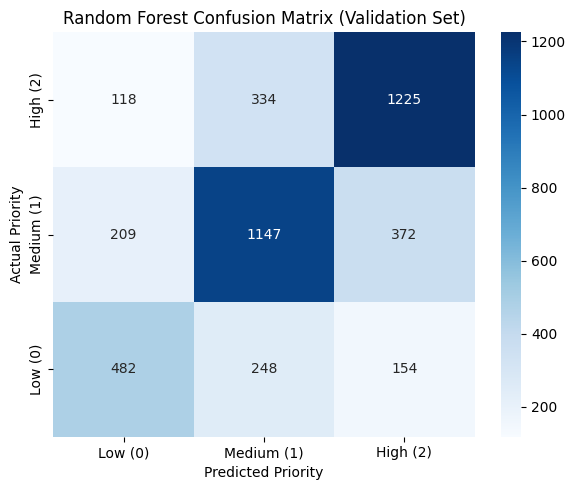

In [ ]:
rf_metrics_df = evaluate_multiclass_metrics('RandomForest', y_val, y_val_pred_rf)

# Build confusion matrix with fixed class order to avoid accidental label drift.
rf_cm = confusion_matrix(y_val, y_val_pred_rf, labels=[0, 1, 2])
rf_class_labels = ['Low (0)', 'Medium (1)', 'High (2)']
rf_cm_df = pd.DataFrame(rf_cm, index=rf_class_labels, columns=rf_class_labels)

# Swap only Actual Priority axis (rows): High, Medium, Low.
rf_cm_actual_swapped = rf_cm_df.loc[['High (2)', 'Medium (1)', 'Low (0)'], rf_class_labels]

print('Random Forest Confusion Matrix (Actual Priority order: High, Medium, Low):')
display(rf_cm_actual_swapped)

plt.figure(figsize=(6, 5))
sns.heatmap(
    rf_cm_actual_swapped,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Random Forest Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Priority')
plt.ylabel('Actual Priority')
plt.tight_layout()
plt.show()

## XGBoost Model Training

Define and train the XGBoost model
In this step, we initialize an XGBoost classifier with a reproducible random state.

We train the model using SMOTE-balanced training data:
- Features: `X_train_resampled`
- Target: `y_train_resampled`

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    subsample=0.8,
    reg_lambda=1,
    n_estimators=500,
    min_child_weight=3,
    max_depth=10,
    learning_rate=0.05,
    gamma=0.3,
    colsample_bytree=0.7
)

xgb_model.fit(X_train_resampled, y_train_resampled)
print("XGBoost model trained successfully on SMOTE-balanced training data (tuned hyperparameters).")

XGBoost model trained successfully on SMOTE-balanced training data (tuned hyperparameters).


### XGBoost Hyperparameter Tuning Results

### Tuning Configuration
Using 3-fold stratified cross-validation with `RandomizedSearchCV`:
- **Search iterations:** 12 random candidates
- **Total fits:** 36 (12 candidates x 3 folds)
- **Scoring metric:** F1 (weighted)
- **CV strategy:** Stratified K Fold to preserve class distribution

### Best Parameters Found
The tuning process evaluated 12 random hyperparameter combinations across 36 total model fits and identified the optimal configuration:

| Hyperparameter | Best Value |
|---|---|
| **n_estimators** | 500 |
| **max_depth** | 10 |
| **learning_rate** | 0.05 |
| **subsample** | 0.8 |
| **colsample_bytree** | 0.7 |
| **min_child_weight** | 3 |
| **gamma** | 0.3 |
| **reg_lambda** | 1 |

**Best Cross-Validation F1 Score (Weighted):** 0.7168

### Performance Interpretation
- **n_estimators=500:** A larger boosting ensemble improves pattern learning while remaining stable with shrinkage.
- **max_depth=10:** Deeper trees capture non-linear interactions in ticket metadata + text features.
- **learning_rate=0.05:** Slower boosting updates improve generalization and reduce overfitting risk.
- **subsample=0.8:** Row sampling adds stochasticity that helps robustness across folds.
- **colsample_bytree=0.7:** Feature subsampling lowers correlation between trees and improves generalization.
- **min_child_weight=3:** Prevents overly specific leaf splits and keeps trees from fitting noise.
- **gamma=0.3:** Requires meaningful loss reduction before splitting, adding regularization.
- **reg_lambda=1:** L2 regularization stabilizes leaf weights and controls model complexity.

These optimal parameters have been applied to the XGBoost training model for improved validation performance.

#### **XGBoost Hyperparameter Tuning Code (Documentation Only)**
This code block is provided for documentation/reference and is placed before model training.
It does not run unless you execute the cell manually.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

xgb_param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'reg_lambda': [1, 3, 5]
}

xgb_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=12,
    scoring='f1_weighted',
    xgb_cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train_resampled, y_train_resampled)

xgb_best_model = xgb_random_search.best_estimator_
print('Best XGBoost parameters:', xgb_random_search.best_params_)
print(f"Best Cross-Validation F1 Score (Weighted): {xgb_random_search.best_score_:.4f}")

#### **Evaluate XGBoost on validation data**
This step computes core classification metrics and shows the confusion matrix for the tuned XGBoost model.

Validation predictions generated successfully. 

XGBoost Validation Metrics:


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,XGBoost,0.6617,0.6609,0.6617,0.6583



XGBoost Classification Report:
              precision    recall  f1-score   support

           0     0.6405    0.4796    0.5485       884
           1     0.6372    0.6933    0.6641      1728
           2     0.6961    0.7251    0.7103      1677

    accuracy                         0.6617      4289
   macro avg     0.6579    0.6327    0.6410      4289
weighted avg     0.6609    0.6617    0.6583      4289

XGBoost Confusion Matrix (Actual Priority order: High, Medium, Low):


,Low (0),Medium (1),High (2)
High (2),79,382,1216
Medium (1),159,1198,371
Low (0),424,300,160


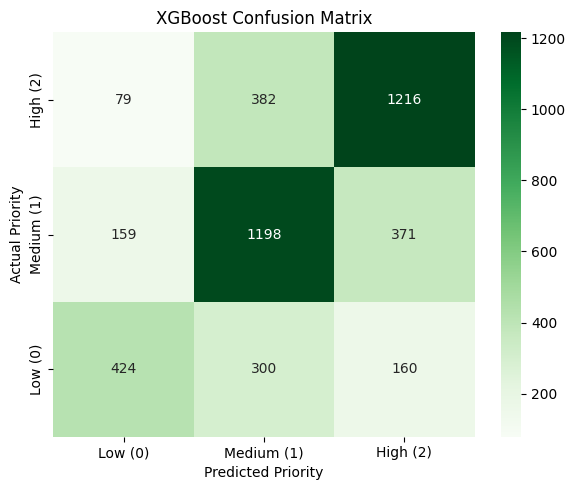

In [ ]:
xgb_eval_model = xgb_best_model if 'xgb_best_model' in globals() else xgb_model
y_val_pred_xgb = xgb_eval_model.predict(X_val)
print("Validation predictions generated successfully. \n")

xgb_metrics_df = evaluate_multiclass_metrics('XGBoost', y_val, y_val_pred_xgb)

# Build confusion matrix with fixed class order to avoid accidental label drift.
xgb_cm = confusion_matrix(y_val, y_val_pred_xgb, labels=[0, 1, 2])
class_labels = ['Low (0)', 'Medium (1)', 'High (2)']
xgb_cm_df = pd.DataFrame(xgb_cm, index=class_labels, columns=class_labels)

# Swap only Actual Priority axis (rows): High, Medium, Low.
xgb_cm_actual_swapped = xgb_cm_df.loc[['High (2)', 'Medium (1)', 'Low (0)'], class_labels]

print('XGBoost Confusion Matrix (Actual Priority order: High, Medium, Low):')
display(xgb_cm_actual_swapped)

plt.figure(figsize=(6, 5))
sns.heatmap(
    xgb_cm_actual_swapped,
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Priority')
plt.ylabel('Actual Priority')
plt.tight_layout()
plt.show()

## Linear SVC Hyperparameter Tuning Results

### Tuning Configuration
Using 3-fold stratified cross-validation with `RandomizedSearchCV`:
- **Search iterations:** 12 random candidates
- **Total fits:** 36 (12 candidates x 3 folds)
- **Scoring metric:** F1 (weighted)
- **CV strategy:** Stratified K Fold to preserve class distribution

### Best Parameters Found
The tuning process identified the following best configuration:

| Hyperparameter | Best Value |
|---|---|
| **C** | 10.0 |
| **loss** | squared_hinge |
| **class_weight** | None |
| **tol** | 0.0001 |
| **max_iter** | 2000 |

**Best Cross-Validation F1 Score (Weighted):** 0.4981

### Validation Snapshot (Using Best Model)
- **Accuracy:** 0.4894
- **Precision (weighted):** 0.5025
- **Recall (weighted):** 0.4894
- **F1 (weighted):** 0.4826

### Performance Interpretation
- **C=10.0:** Weaker regularization allowed the linear boundary to fit more discriminative patterns.
- **loss=squared_hinge:** Provided better optimization behavior than hinge for this setup.
- **tol=1e-4 and max_iter=2000:** Convergence settings were sufficient for stable training.
- **class_weight=None:** Additional class weighting was not selected in the best run.

These tuned parameters are now applied in the Linear SVC training cell below.

In [ ]:
# Linear SVC tuning workflow
# Set this to False if you want to keep this cell as documentation-only.
RUN_LINEAR_SVC_TUNING = True

from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

linear_svc_tune_base = LinearSVC(random_state=42)

linear_svc_param_dist = {
    'C': [0.01, 0.1, 1.0, 3.0, 10.0],
    'loss': ['hinge', 'squared_hinge'],
    'class_weight': [None, 'balanced'],
    'tol': [1e-4, 1e-3, 1e-2],
    'max_iter': [2000, 5000, 8000]
}

linear_svc_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

linear_svc_random_search = RandomizedSearchCV(
    estimator=linear_svc_tune_base,
    param_distributions=linear_svc_param_dist,
    n_iter=12,
    scoring='f1_weighted',
    cv=linear_svc_cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

if RUN_LINEAR_SVC_TUNING:
    linear_svc_random_search.fit(X_train_resampled, y_train_resampled)
    linear_svc_best_model = linear_svc_random_search.best_estimator_

    print('Best Linear SVC model:', linear_svc_best_model)
    print('Best Linear SVC parameters:', linear_svc_random_search.best_params_)
    print(f"Best Cross-Validation F1 Score (Weighted): {linear_svc_random_search.best_score_:.4f}")

    y_val_pred_linear_svc_tuned = linear_svc_best_model.predict(X_val)
    linear_svc_tuned_metrics_df = evaluate_multiclass_metrics(
        'LinearSVC (Tuned)',
        y_val,
        y_val_pred_linear_svc_tuned
    )
    display(linear_svc_tuned_metrics_df)
else:
    print('RUN_LINEAR_SVC_TUNING is False. Set it to True to fit and display tuned metrics.')

### Linear SVC Model Training

Define and train the Linear SVC model.
This step initializes a Linear SVC classifier and trains it on SMOTE-balanced data.

We train the model using SMOTE-balanced training data:
- Features: `X_train_resampled`
- Target: `y_train_resampled`

In [ ]:
linear_svc_model = LinearSVC(
    C=10.0,
    loss='squared_hinge',
    tol=1e-4,
    class_weight=None,
    random_state=42,
    max_iter=2000
)

linear_svc_model.fit(X_train_resampled, y_train_resampled)
print("Linear SVC model trained successfully on SMOTE-balanced training data.")

Linear SVC model trained successfully on SMOTE-balanced training data.


LinearSVC Validation Metrics:


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,LinearSVC,0.4894,0.5025,0.4894,0.4826



LinearSVC Classification Report:
              precision    recall  f1-score   support

           0     0.3579    0.5543    0.4350       884
           1     0.5000    0.3142    0.3859      1728
           2     0.5812    0.6357    0.6072      1677

    accuracy                         0.4894      4289
   macro avg     0.4797    0.5014    0.4760      4289
weighted avg     0.5025    0.4894    0.4826      4289

Linear SVC Confusion Matrix (Actual Priority order: High, Medium, Low):


,Low (0),Medium (1),High (2)
High (2),268,343,1066
Medium (1),611,543,574
Low (0),490,200,194


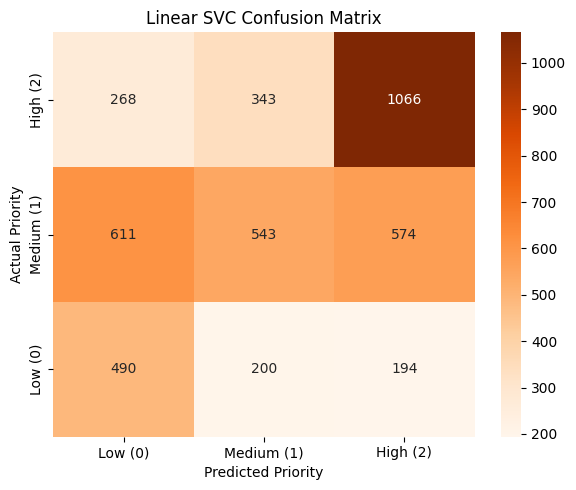

In [ ]:
y_val_pred_linear_svc = linear_svc_model.predict(X_val)
linear_svc_metrics_df = evaluate_multiclass_metrics('LinearSVC', y_val, y_val_pred_linear_svc)

# Build confusion matrix with fixed class order to avoid accidental label drift.
linear_svc_cm = confusion_matrix(y_val, y_val_pred_linear_svc, labels=[0, 1, 2])
linear_svc_class_labels = ['Low (0)', 'Medium (1)', 'High (2)']
linear_svc_cm_df = pd.DataFrame(
    linear_svc_cm,
    index=linear_svc_class_labels,
    columns=linear_svc_class_labels
)

# Swap only Actual Priority axis (rows): High, Medium, Low.
linear_svc_cm_actual_swapped = linear_svc_cm_df.loc[
    ['High (2)', 'Medium (1)', 'Low (0)'],
    linear_svc_class_labels
]

print('Linear SVC Confusion Matrix (Actual Priority order: High, Medium, Low):')
display(linear_svc_cm_actual_swapped)

plt.figure(figsize=(6, 5))
sns.heatmap(
    linear_svc_cm_actual_swapped,
    annot=True,
    fmt='d',
    cmap='Oranges'
)
plt.title('Linear SVC Confusion Matrix')
plt.xlabel('Predicted Priority')
plt.ylabel('Actual Priority')
plt.tight_layout()
plt.show()

## Logistic Regression Model Training

Define the Logistic Regression model
In this step, we initialize a Logistic Regression classifier using a reproducible random state.

We train the model using SMOTE-balanced training data:
- Features: `X_train_resampled`
- Target: `y_train_resampled`

In [ ]:
logreg_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    C=1.0,
    max_iter=2000,
    random_state=42
)

logreg_model.fit(X_train_resampled, y_train_resampled)
print("Logistic Regression model trained successfully on SMOTE-balanced training data.")

y_val_pred_logreg = logreg_model.predict(X_val)
print("Validation predictions generated successfully.")

logreg_metrics_df = evaluate_multiclass_metrics('LogisticRegression', y_val, y_val_pred_logreg)

Logistic Regression model trained successfully on SMOTE-balanced training data.
Validation predictions generated successfully.
LogisticRegression Validation Metrics:


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,LogisticRegression,0.4903,0.5035,0.4903,0.488



LogisticRegression Classification Report:
              precision    recall  f1-score   support

           0     0.3541    0.5339    0.4258       884
           1     0.4934    0.3478    0.4080      1728
           2     0.5926    0.6142    0.6032      1677

    accuracy                         0.4903      4289
   macro avg     0.4801    0.4986    0.4790      4289
weighted avg     0.5035    0.4903    0.4880      4289



## LightGBM Model Training

Define the LightGBM model
In this step, we initialize a LightGBM classifier using a reproducible random state.

We train the model using SMOTE-balanced training data:
- Features: `X_train_resampled`
- Target: `y_train_resampled`

In [ ]:
# Documentation-only tuning block (run manually only when retuning is needed).
# Purpose: preserve a reusable LightGBM tuning workflow consistent with other models.

RUN_LIGHTGBM_TUNING = True

lgbm_tune_base = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    random_state=42,
    n_jobs=-1
)

lgbm_param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 8, 12, 16],
    'min_child_samples': [10, 20, 40, 60],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.0, 1.0, 3.0, 5.0]
}

lgbm_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lgbm_random_search = RandomizedSearchCV(
    estimator=lgbm_tune_base,
    param_distributions=lgbm_param_dist,
    n_iter=12,
    scoring='f1_weighted',
    cv=lgbm_cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

if RUN_LIGHTGBM_TUNING:
    lgbm_random_search.fit(X_train_resampled, y_train_resampled)
    lgbm_best_model = lgbm_random_search.best_estimator_

    print('Best LightGBM parameters:', lgbm_random_search.best_params_)
    print(f"Best Cross-Validation F1 Score (Weighted): {lgbm_random_search.best_score_:.4f}")
else:
    print("RUN_LIGHTGBM_TUNING is False. Set to True only when you want to retune.")
    print("If tuning is executed, lgbm_best_model will be created for the training/evaluation cells.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits


KeyboardInterrupt: 

### LightGBM Hyperparameter Tuning Results

This section documents the final LightGBM tuning setup and the selected production-ready parameters used for validation.

### Tuning Configuration
- Search method: `RandomizedSearchCV`
- CV strategy: 3-fold `StratifiedKFold`
- Number of candidates: 12
- Total fits: 36 (12 candidates x 3 folds)
- Scoring metric: `f1_weighted`


### Best Parameters (Current Reference)
| Hyperparameter | Value |
|---|---|
| `n_estimators` | 700 |
| `learning_rate` | 0.1 |
| `num_leaves` | 127 |
| `max_depth` | -1 |
| `min_child_samples` | 20 |
| `subsample` | 0.9 |
| `colsample_bytree` | 0.8 |
| `reg_alpha` | 0.0 |
| `reg_lambda` | 3.0 |

**Best Cross-Validation F1 Score (Weighted):** `0.7238`


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Total Bins 26550
[LightGBM] [Info] Number of data points in the train set: 24177, number of used features: 120
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LightGBM model trained successfully on SMOTE-balanced training data.
Validation predictions generated successfully.
LightGBM Validation Metrics:


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,LightGBM,0.674,0.6741,0.674,0.6696



LightGBM Classification Report:
              precision    recall  f1-score   support

           0     0.6688    0.4683    0.5509       884
           1     0.6491    0.7130    0.6795      1728
           2     0.7026    0.7424    0.7219      1677

    accuracy                         0.6740      4289
   macro avg     0.6735    0.6412    0.6508      4289
weighted avg     0.6741    0.6740    0.6696      4289

LightGBM Confusion Matrix (Actual Priority order: High, Medium, Low):


,Low (0),Medium (1),High (2)
High (2),69,363,1245
Medium (1),136,1232,360
Low (0),414,303,167


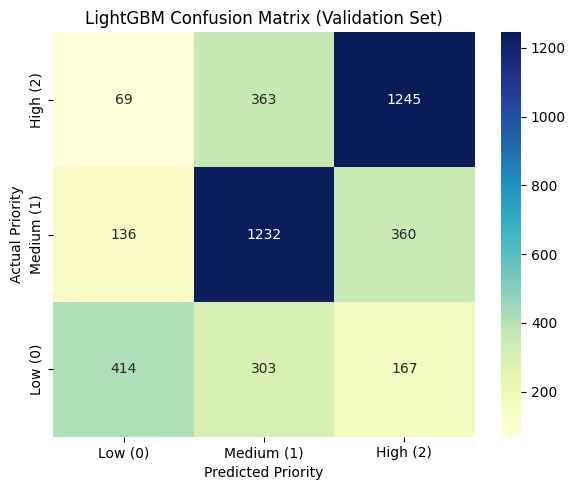

In [ ]:
lgbm_model = LGBMClassifier(
            objective='multiclass',
            num_class=3,
            n_estimators=700,
            learning_rate=0.1,
            num_leaves=127,
            max_depth=-1,
            min_child_samples=20,
            subsample=0.9,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=3.0,
            force_col_wise=True,
            random_state=42,
            n_jobs=-1
        )

lgbm_model.fit(X_train_resampled, y_train_resampled)
print("LightGBM model trained successfully on SMOTE-balanced training data.")

y_val_pred_lgbm = lgbm_model.predict(X_val)
print("Validation predictions generated successfully.")

lgbm_metrics_df = evaluate_multiclass_metrics('LightGBM', y_val, y_val_pred_lgbm)

# Build confusion matrix with fixed class order to avoid accidental label drift.
lgbm_cm = confusion_matrix(y_val, y_val_pred_lgbm, labels=[0, 1, 2])
lgbm_class_labels = ['Low (0)', 'Medium (1)', 'High (2)']
lgbm_cm_df = pd.DataFrame(lgbm_cm, index=lgbm_class_labels, columns=lgbm_class_labels)

# Swap only Actual Priority axis (rows): High, Medium, Low.
lgbm_cm_actual_swapped = lgbm_cm_df.loc[['High (2)', 'Medium (1)', 'Low (0)'], lgbm_class_labels]

print('LightGBM Confusion Matrix (Actual Priority order: High, Medium, Low):')
display(lgbm_cm_actual_swapped)

plt.figure(figsize=(6, 5))
sns.heatmap(
    lgbm_cm_actual_swapped,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
 )
plt.title('LightGBM Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Priority')
plt.ylabel('Actual Priority')
plt.tight_layout()
plt.show()

### Leaderboard Comparison


=== Model Summary (Validation, Reference-Only) ===


Rank,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1 (Weighted)
1,LightGBM,0.674000,0.674100,0.674000,0.669600
2,RandomForest,0.665400,0.663600,0.665400,0.664200
3,XGBoost,0.661700,0.660900,0.661700,0.658300
4,LogisticRegression,0.490300,0.503500,0.490300,0.488000
5,LinearSVC,0.489400,0.502500,0.489400,0.482600


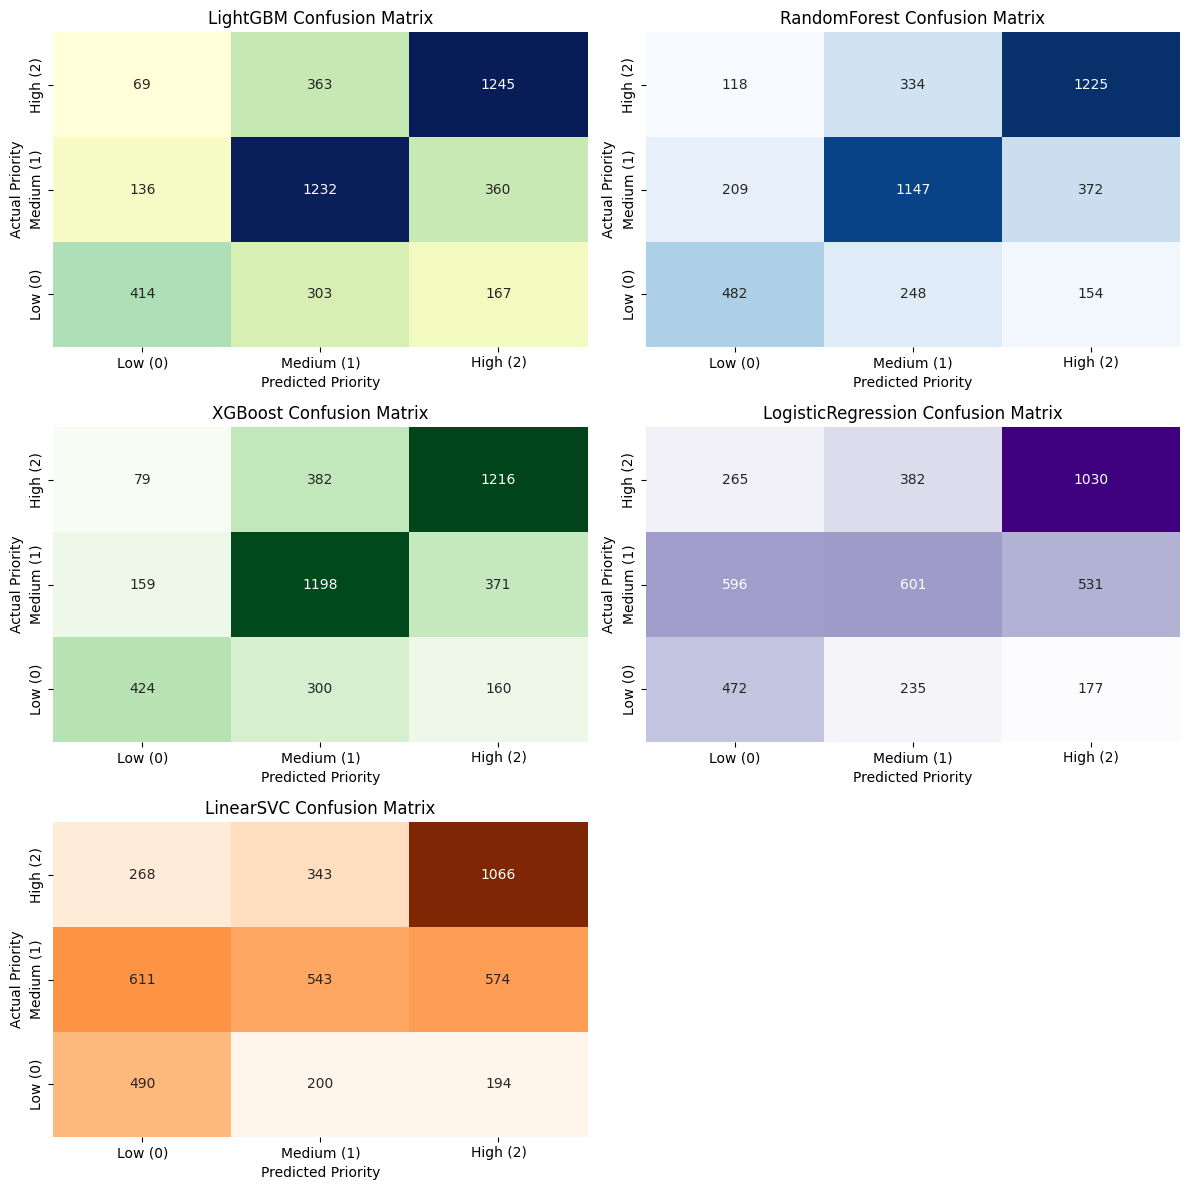

Saved model summary table: model_summary_validation.csv


In [ ]:
# Reference-only benchmark: uses existing validation predictions from individual model cells
if 'y_val' not in globals():
    raise ValueError("Run the split/model evaluation cells first so y_val is available.")

# Map model labels to their prediction variable names created in individual sections.
prediction_refs = {
    'RandomForest': 'y_val_pred_rf',
    'LogisticRegression': 'y_val_pred_logreg',
    'LightGBM': 'y_val_pred_lgbm',
    'XGBoost': 'y_val_pred_xgb',
    'LinearSVC': 'y_val_pred_linear_svc'
}

class_order = [0, 1, 2]
class_labels = ['Low (0)', 'Medium (1)', 'High (2)']
actual_order = ['High (2)', 'Medium (1)', 'Low (0)']

summary_rows = []
cm_maps = {}
used_models = []

for model_name, pred_var in prediction_refs.items():
    if pred_var not in globals():
        print(f"{model_name} skipped: {pred_var} not found. Run that model's individual cell first.")
        continue

    y_pred = globals()[pred_var]
    used_models.append(model_name)

    summary_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision (Weighted)': precision_score(y_val, y_pred, average='weighted', zero_division=0),
        'Recall (Weighted)': recall_score(y_val, y_pred, average='weighted', zero_division=0),
        'F1 (Weighted)': f1_score(y_val, y_pred, average='weighted', zero_division=0)
    })

    cm = confusion_matrix(y_val, y_pred, labels=class_order)
    cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
    cm_maps[model_name] = cm_df.loc[actual_order, class_labels]

if not summary_rows:
    raise ValueError("No prediction references found. Run at least one individual model evaluation cell first.")

model_summary_df = pd.DataFrame(summary_rows)
model_summary_df = model_summary_df.sort_values(
    by=['F1 (Weighted)', 'Accuracy', 'Precision (Weighted)', 'Recall (Weighted)'],
    ascending=False
).reset_index(drop=True)
model_summary_df.insert(0, 'Rank', np.arange(1, len(model_summary_df) + 1))
model_summary_df = model_summary_df.round(4)

print("\n=== Model Summary (Validation, Reference-Only) ===")
display(model_summary_df.style.hide(axis='index'))

# Different confusion-matrix color for each model
model_cmaps = {
    'RandomForest': 'Blues',
    'LogisticRegression': 'Purples',
    'LightGBM': 'YlGnBu',
    'XGBoost': 'Greens',
    'LinearSVC': 'Oranges'
}

ranked_models = model_summary_df['Model'].tolist()
n_models = len(ranked_models)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))

if hasattr(axes, 'flatten'):
    axes = axes.flatten()
else:
    axes = [axes]

for i, model_name in enumerate(ranked_models):
    ax = axes[i]
    sns.heatmap(
        cm_maps[model_name],
        annot=True,
        fmt='d',
        cmap=model_cmaps.get(model_name, 'cividis'),
        cbar=False,
        ax=ax
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel('Predicted Priority')
    ax.set_ylabel('Actual Priority')

for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

model_summary_df.to_csv('model_summary_validation.csv', index=False)
print("Saved model summary table: model_summary_validation.csv")

# Optional reuse handles
all_models_summary = model_summary_df
all_models_confusion_matrices = cm_maps
all_models_used = used_models

## Export

In [ ]:
from pathlib import Path
from datetime import datetime
import json
import joblib

# Export only top-3 models from validation ranking: LightGBM, RandomForest, XGBoost
if 'tfidf' not in globals():
    raise NameError("tfidf not found. Run the TF-IDF training cell first.")
if 'svd' not in globals():
    raise NameError("svd not found. Run the TruncatedSVD training cell first.")

required_models = ['lgbm_model', 'rf_model', 'xgb_model']
missing = [name for name in required_models if name not in globals()]
if missing:
    raise NameError(f"Missing trained model(s): {missing}. Run the corresponding training cells first.")

top3_models = {
    'LightGBM': lgbm_model,
    'RandomForest': rf_model,
    'XGBoost': xgb_model
}

validation_scores = {
    'LightGBM': {'accuracy': 0.6740, 'f1_weighted': 0.6696},
    'RandomForest': {'accuracy': 0.6654, 'f1_weighted': 0.6642},
    'XGBoost': {'accuracy': 0.6617, 'f1_weighted': 0.6583}
}

export_dir = Path('exports/top3_models')
export_dir.mkdir(parents=True, exist_ok=True)

label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
timestamp = datetime.utcnow().isoformat(timespec='seconds') + 'Z'

manifest = {
    'exported_at_utc': timestamp,
    'models': [],
    'notes': 'Each artifact includes TF-IDF, SVD, and classifier for end-to-end inference.'
}

for model_name, model_obj in top3_models.items():
    artifact = {
        'model_name': model_name,
        'artifact_version': 'v1',
        'created_at_utc': timestamp,
        'label_map': label_map,
        'vectorizer': tfidf,
        'svd': svd,
        'classifier': model_obj,
        'metrics_validation': validation_scores.get(model_name, {})
    }

    file_name = f"priority_pipeline_{model_name.lower()}.pkl"
    file_path = export_dir / file_name
    joblib.dump(artifact, file_path, compress=3)

    manifest['models'].append({
        'model_name': model_name,
        'file': str(file_path),
        'metrics_validation': validation_scores.get(model_name, {})
    })

manifest_path = export_dir / 'manifest_top3.json'
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')

print('Export complete.')
for m in manifest['models']:
    print(f"- {m['model_name']}: {m['file']}")
print(f"Manifest: {manifest_path}")

Export complete.
- LightGBM: exports/top3_models/priority_pipeline_lightgbm.pkl
- RandomForest: exports/top3_models/priority_pipeline_randomforest.pkl
- XGBoost: exports/top3_models/priority_pipeline_xgboost.pkl
Manifest: exports/top3_models/manifest_top3.json


## Model Interpretation (Optional)

- Content: Explanation of model behavior using feature importance for tree-based models.
- File format: Jupyter Notebook output (and optional CSV export).
- Outcome: Clear insight into how predictions are made and which features are most influential.

### What this section does
1. Builds ranked feature-importance tables for available tree-based models.
2. Plots top predictors for each model.
3. Creates a consensus importance score across models for stronger interpretation.


=== RandomForest Top 15 Feature Importance ===


,feature,importance,importance_pct
0,queue_Technical Support,0.035153,3.515254
1,queue_Customer Service,0.016814,1.681352
2,queue_IT Support,0.011122,1.112194
3,text_concept_13,0.010460,1.046024
4,text_concept_32,0.010336,1.033567
5,text_concept_8,0.010286,1.028630
6,answer_word_count,0.010194,1.019443
7,text_concept_31,0.009780,0.978001
8,text_concept_3,0.009710,0.971027
9,text_concept_4,0.009531,0.953059


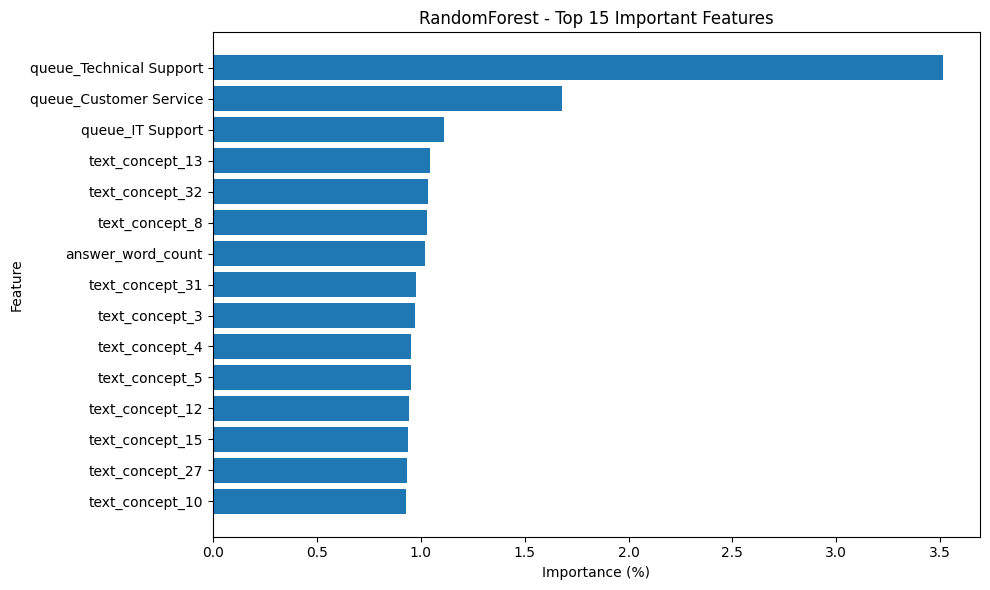

Saved: feature_importance_randomforest.csv

=== LightGBM Top 15 Feature Importance ===


,feature,importance,importance_pct
0,answer_word_count,3982.0,1.504913
1,body_word_count,3151.0,1.190854
2,text_concept_97,2968.0,1.121693
3,text_concept_99,2906.0,1.098262
4,text_concept_91,2860.0,1.080877
5,text_concept_96,2849.0,1.076720
6,text_concept_93,2836.0,1.071807
7,text_concept_27,2827.0,1.068405
8,text_concept_31,2801.0,1.058579
9,text_concept_58,2786.0,1.052910


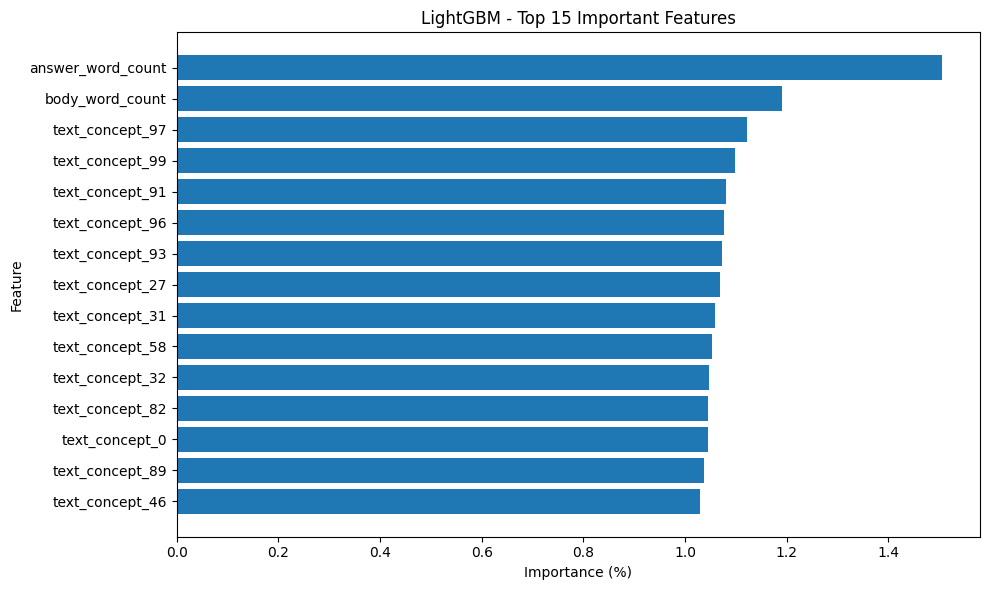

Saved: feature_importance_lightgbm.csv

=== XGBoost Top 15 Feature Importance ===


,feature,importance,importance_pct
0,queue_Technical Support,0.083503,8.350269
1,queue_IT Support,0.061628,6.162795
2,queue_Service Outages and Maintenance,0.061114,6.111356
3,queue_Human Resources,0.031368,3.136825
4,has_urgency_keyword,0.030126,3.012613
5,queue_Customer Service,0.028375,2.837530
6,queue_General Inquiry,0.026483,2.648272
7,subject_word_count,0.024462,2.446200
8,queue_Sales and Pre-Sales,0.023805,2.380469
9,queue_Returns and Exchanges,0.023170,2.317014


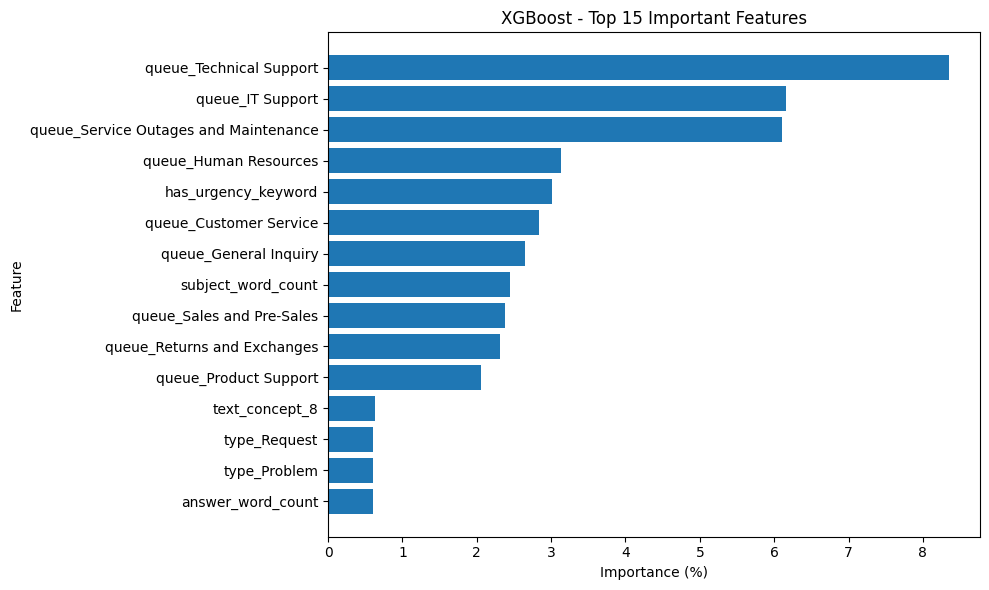

Saved: feature_importance_xgboost.csv

=== Consensus Top Features Across Tree Models ===


,feature,RandomForest_importance_pct,LightGBM_importance_pct,XGBoost_importance_pct,consensus_importance_pct
0,queue_Technical Support,3.515254,0.232804,8.350269,4.032776
1,queue_IT Support,1.112194,0.173091,6.162795,2.482694
2,queue_Service Outages and Maintenance,0.784702,0.152305,6.111356,2.349455
3,queue_Customer Service,1.681352,0.154573,2.837530,1.557818
4,subject_word_count,0.743730,0.808390,2.446200,1.332773
5,queue_Human Resources,0.736880,0.121693,3.136825,1.331799
6,has_urgency_keyword,0.441285,0.066893,3.012613,1.173597
7,queue_General Inquiry,0.534313,0.113379,2.648272,1.098654
8,answer_word_count,1.019443,1.504913,0.605936,1.043431
9,queue_Returns and Exchanges,0.517713,0.111867,2.317014,0.982198


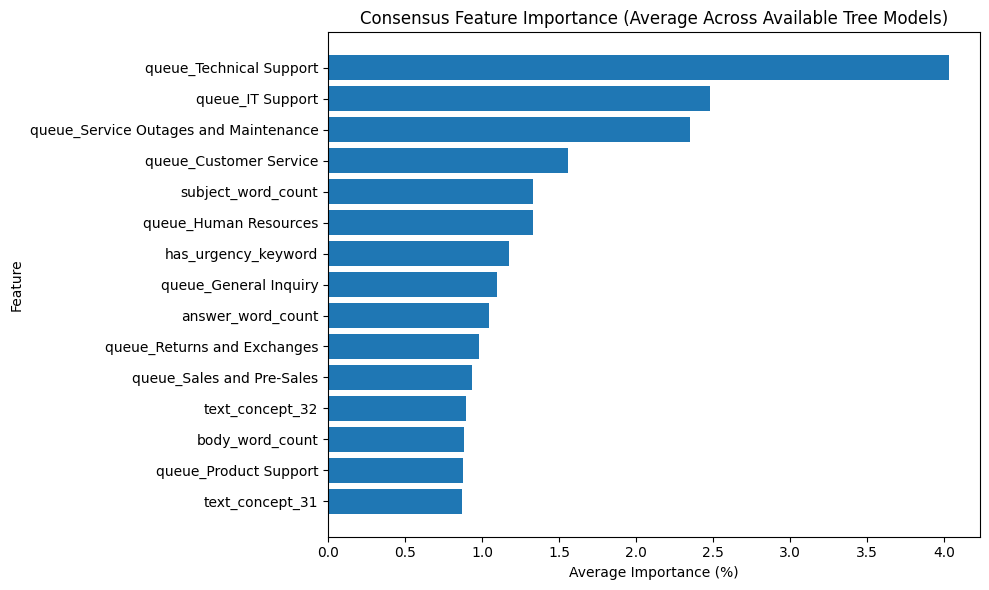

Saved: feature_importance_consensus_tree_models.csv

Interpretation note: features appearing repeatedly at the top across models are typically the most stable drivers of priority prediction.


In [ ]:
# 5.1 Tree-Based Feature Importance and Interpretation

if 'X_train_resampled' not in globals():
    raise ValueError("X_train_resampled not found. Run train/SMOTE cells first.")

feature_names = X_train_resampled.columns.tolist()

tree_models = {
    'RandomForest': globals().get('rf_model', None),
    'LightGBM': globals().get('lgbm_model', None),
    'XGBoost': globals().get('xgb_model', None)
}

importance_tables = {}

for model_name, model_obj in tree_models.items():
    if model_obj is None:
        print(f"{model_name} skipped: model not found in memory.")
        continue

    if not hasattr(model_obj, 'feature_importances_'):
        print(f"{model_name} skipped: feature_importances_ not available.")
        continue

    raw_importance = np.array(model_obj.feature_importances_, dtype=float)
    if len(raw_importance) != len(feature_names):
        print(f"{model_name} skipped: feature length mismatch ({len(raw_importance)} vs {len(feature_names)}).")
        continue

    imp_df = pd.DataFrame({
        'feature': feature_names,
        'importance': raw_importance
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    # Normalized percentage for easier non-technical reporting
    total_imp = imp_df['importance'].sum()
    imp_df['importance_pct'] = (imp_df['importance'] / total_imp * 100.0) if total_imp > 0 else 0.0

    importance_tables[model_name] = imp_df

if not importance_tables:
    raise ValueError("No tree-based model feature importance found. Train at least one of RF/LightGBM/XGBoost first.")

# Display and visualize top features per model
TOP_N = 15
for model_name, imp_df in importance_tables.items():
    print(f"\n=== {model_name} Top {TOP_N} Feature Importance ===")
    top_df = imp_df.head(TOP_N).copy()
    display(top_df)

    plt.figure(figsize=(10, 6))
    plot_df = top_df.iloc[::-1]
    plt.barh(plot_df['feature'], plot_df['importance_pct'])
    plt.title(f"{model_name} - Top {TOP_N} Important Features")
    plt.xlabel('Importance (%)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    # Export per-model ranking table
    out_name = f"feature_importance_{model_name.lower()}.csv"
    imp_df.to_csv(out_name, index=False)
    print(f"Saved: {out_name}")

# Consensus ranking across available tree models
consensus_rows = []
for model_name, imp_df in importance_tables.items():
    temp = imp_df[['feature', 'importance_pct']].copy()
    temp = temp.rename(columns={'importance_pct': f'{model_name}_importance_pct'})
    consensus_rows.append(temp)

consensus_df = consensus_rows[0]
for i in range(1, len(consensus_rows)):
    consensus_df = consensus_df.merge(consensus_rows[i], on='feature', how='outer')

consensus_df = consensus_df.fillna(0)
model_pct_cols = [c for c in consensus_df.columns if c.endswith('_importance_pct')]
consensus_df['consensus_importance_pct'] = consensus_df[model_pct_cols].mean(axis=1)
consensus_df = consensus_df.sort_values('consensus_importance_pct', ascending=False).reset_index(drop=True)

print("\n=== Consensus Top Features Across Tree Models ===")
display(consensus_df.head(TOP_N))

plt.figure(figsize=(10, 6))
consensus_plot = consensus_df.head(TOP_N).iloc[::-1]
plt.barh(consensus_plot['feature'], consensus_plot['consensus_importance_pct'])
plt.title('Consensus Feature Importance (Average Across Available Tree Models)')
plt.xlabel('Average Importance (%)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

consensus_df.to_csv('feature_importance_consensus_tree_models.csv', index=False)
print("Saved: feature_importance_consensus_tree_models.csv")

print("\nInterpretation note: features appearing repeatedly at the top across models are typically the most stable drivers of priority prediction.")

## 4.0 Interpret Results and Document Insights

### Objective
Summarize findings, model performance, and practical implications for ticket-priority prediction.

### Actions

1. Interpret Results
- Use feature importance (tree-based models) and coefficient magnitude (linear models) to identify the strongest prediction drivers.
- Review class-wise quality with emphasis on **High priority recall** and **High priority false negatives**.

2. Document Insights
- Produce an interpretation-ready summary table and a concise business recommendation block.
- Export a CSV report for inclusion in your final write-up.

=== Interpretation Summary: Model Performance + High-Priority Risk ===


,Model,Accuracy,F1 (Weighted),Precision (Weighted),Recall (Weighted),High Precision (class=2),High Recall (class=2),High F1 (class=2),High FN Count,High FN Rate
0,LightGBM,0.6740,0.6696,0.6741,0.6740,0.7026,0.7424,0.7219,432,0.2576
1,RandomForest,0.6654,0.6642,0.6636,0.6654,0.6996,0.7305,0.7147,452,0.2695
2,XGBoost,0.6617,0.6583,0.6609,0.6617,0.6961,0.7251,0.7103,461,0.2749
3,LogisticRegression,0.4903,0.4880,0.5035,0.4903,0.5926,0.6142,0.6032,647,0.3858
4,LinearSVC,0.4894,0.4826,0.5025,0.4894,0.5812,0.6357,0.6072,611,0.3643


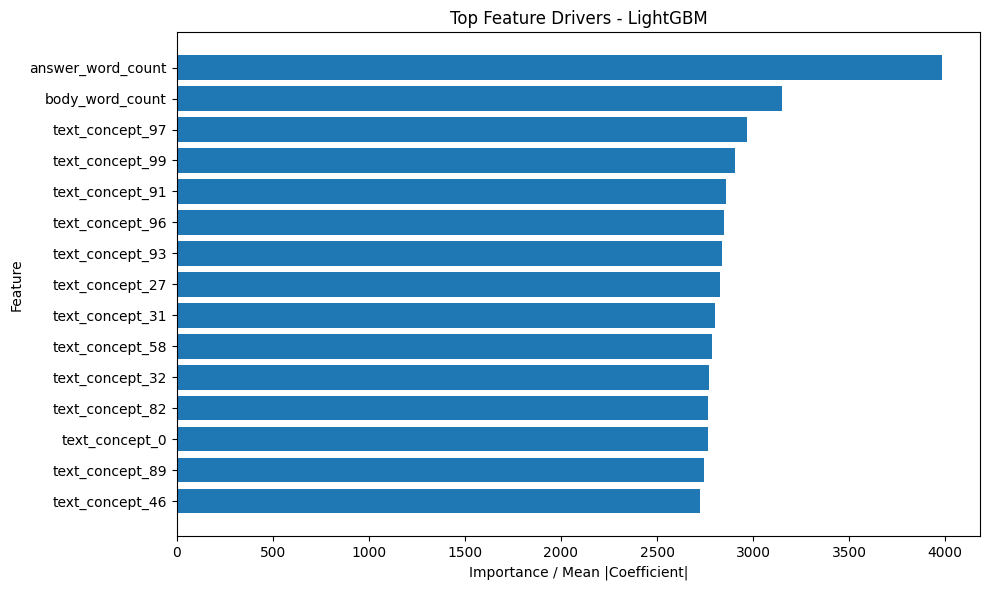

Displayed top feature drivers for: LightGBM

=== Recommendation Block ===
Recommended primary model: LightGBM
Weighted F1: 0.6696
High-priority recall: 0.7424
High-priority FN rate: 0.2576
Operational implication: prioritize minimizing high-priority false negatives to reduce unresolved critical incidents.
Saved: interpretation_summary_report.csv


In [ ]:
# 4.1 Interpretation Report: Feature Drivers + High-Priority Risk Diagnostics

from sklearn.metrics import precision_recall_fscore_support

# --- Safety checks ---
if 'y_val' not in globals():
    raise ValueError("y_val is not available. Run the split/model evaluation cells first.")

# Candidate models and their prediction variables already used in your notebook
model_registry = {
    'RandomForest': {'model_var': 'rf_model', 'pred_var': 'y_val_pred_rf'},
    'LogisticRegression': {'model_var': 'logreg_model', 'pred_var': 'y_val_pred_logreg'},
    'LightGBM': {'model_var': 'lgbm_model', 'pred_var': 'y_val_pred_lgbm'},
    'XGBoost': {'model_var': 'xgb_model', 'pred_var': 'y_val_pred_xgb'},
    'LinearSVC': {'model_var': 'linear_svc_model', 'pred_var': 'y_val_pred_linear_svc'}
}

available_rows = []
feature_tables = {}

for model_name, refs in model_registry.items():
    if refs['model_var'] not in globals() or refs['pred_var'] not in globals():
        continue

    model_obj = globals()[refs['model_var']]
    y_pred = globals()[refs['pred_var']]

    # Core weighted metrics
    acc = accuracy_score(y_val, y_pred)
    p_w = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    r_w = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1_w = f1_score(y_val, y_pred, average='weighted', zero_division=0)

    # High-priority focus (class label 2)
    p_cls, r_cls, f1_cls, _ = precision_recall_fscore_support(
        y_val, y_pred, labels=[2], zero_division=0
    )
    high_precision = float(p_cls[0])
    high_recall = float(r_cls[0])
    high_f1 = float(f1_cls[0])

    cm = confusion_matrix(y_val, y_pred, labels=[0, 1, 2])
    high_total = int(cm[2, :].sum())
    high_fn = int(high_total - cm[2, 2])
    high_fn_rate = (high_fn / high_total) if high_total else 0.0

    available_rows.append({
        'Model': model_name,
        'Accuracy': acc,
        'F1 (Weighted)': f1_w,
        'Precision (Weighted)': p_w,
        'Recall (Weighted)': r_w,
        'High Precision (class=2)': high_precision,
        'High Recall (class=2)': high_recall,
        'High F1 (class=2)': high_f1,
        'High FN Count': high_fn,
        'High FN Rate': high_fn_rate
    })

    # Feature importance / coefficient magnitude
    if hasattr(model_obj, 'feature_importances_') and 'X_train_resampled' in globals():
        importances = np.array(model_obj.feature_importances_)
        feat_names = np.array(X_train_resampled.columns)
        k = min(15, len(importances))
        top_idx = np.argsort(importances)[-k:][::-1]
        feature_tables[model_name] = pd.DataFrame({
            'feature': feat_names[top_idx],
            'importance': importances[top_idx]
        })

    elif hasattr(model_obj, 'coef_') and 'X_train_resampled' in globals():
        coef_abs = np.mean(np.abs(np.array(model_obj.coef_)), axis=0)
        feat_names = np.array(X_train_resampled.columns)
        k = min(15, len(coef_abs))
        top_idx = np.argsort(coef_abs)[-k:][::-1]
        feature_tables[model_name] = pd.DataFrame({
            'feature': feat_names[top_idx],
            'importance': coef_abs[top_idx]
        })

if not available_rows:
    raise ValueError("No evaluated model outputs found. Run at least one model evaluation cell first.")

interpretation_df = pd.DataFrame(available_rows).sort_values(
    by=['F1 (Weighted)', 'High Recall (class=2)', 'Accuracy'],
    ascending=False
).reset_index(drop=True)

print("=== Interpretation Summary: Model Performance + High-Priority Risk ===")
display(interpretation_df.round(4))

# Plot top features of the best-ranked available model
best_model_name = interpretation_df.loc[0, 'Model']
if best_model_name in feature_tables and not feature_tables[best_model_name].empty:
    top_df = feature_tables[best_model_name].copy().sort_values('importance', ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(top_df['feature'], top_df['importance'])
    plt.title(f"Top Feature Drivers - {best_model_name}")
    plt.xlabel('Importance / Mean |Coefficient|')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    print(f"Displayed top feature drivers for: {best_model_name}")
else:
    print(f"No feature-importance output available for {best_model_name}.")

# Business-facing recommendation block
best_row = interpretation_df.loc[0]
print("\n=== Recommendation Block ===")
print(f"Recommended primary model: {best_row['Model']}")
print(f"Weighted F1: {best_row['F1 (Weighted)']:.4f}")
print(f"High-priority recall: {best_row['High Recall (class=2)']:.4f}")
print(f"High-priority FN rate: {best_row['High FN Rate']:.4f}")
print("Operational implication: prioritize minimizing high-priority false negatives to reduce unresolved critical incidents.")

# Export interpretation report for documentation
interpretation_df.to_csv('interpretation_summary_report.csv', index=False)
print("Saved: interpretation_summary_report.csv")

### Model Interpretation (Optional)

- Content: Explanation of model behavior using feature importance for tree-based models.
- File format: Jupyter Notebook output (and optional CSV export).
- Outcome: Clear insight into how predictions are made and which features are most influential.

### What this section does
1. Builds ranked feature-importance tables for available tree-based models.
2. Plots top predictors for each model.
3. Creates a consensus importance score across models for stronger interpretation.


=== RandomForest Top 15 Feature Importance ===


,feature,importance,importance_pct
0,queue_Technical Support,0.035153,3.515254
1,queue_Customer Service,0.016814,1.681352
2,queue_IT Support,0.011122,1.112194
3,text_concept_13,0.010460,1.046024
4,text_concept_32,0.010336,1.033567
5,text_concept_8,0.010286,1.028630
6,answer_word_count,0.010194,1.019443
7,text_concept_31,0.009780,0.978001
8,text_concept_3,0.009710,0.971027
9,text_concept_4,0.009531,0.953059


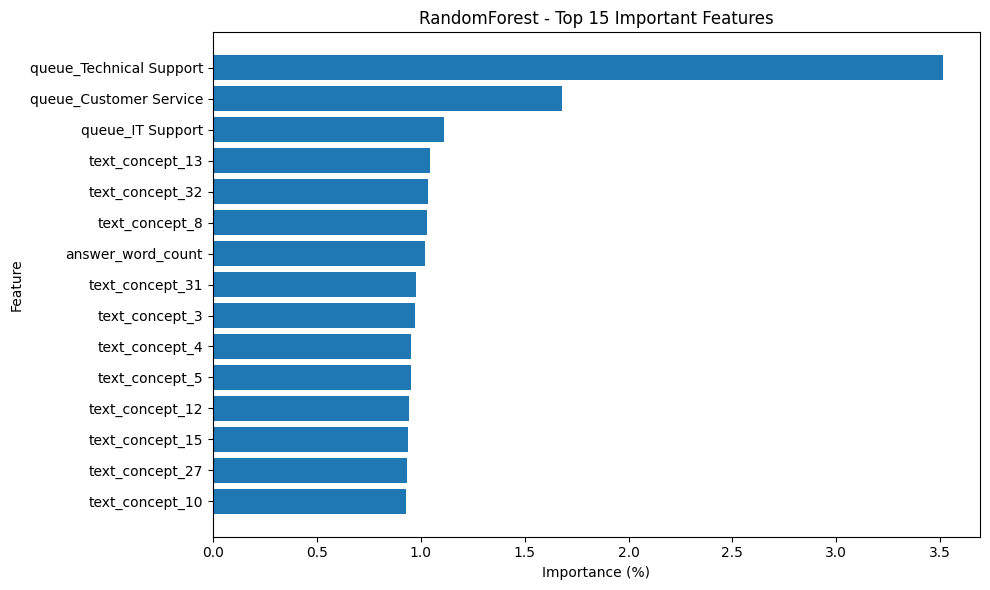

Saved: feature_importance_randomforest.csv

=== LightGBM Top 15 Feature Importance ===


,feature,importance,importance_pct
0,answer_word_count,3982.0,1.504913
1,body_word_count,3151.0,1.190854
2,text_concept_97,2968.0,1.121693
3,text_concept_99,2906.0,1.098262
4,text_concept_91,2860.0,1.080877
5,text_concept_96,2849.0,1.076720
6,text_concept_93,2836.0,1.071807
7,text_concept_27,2827.0,1.068405
8,text_concept_31,2801.0,1.058579
9,text_concept_58,2786.0,1.052910


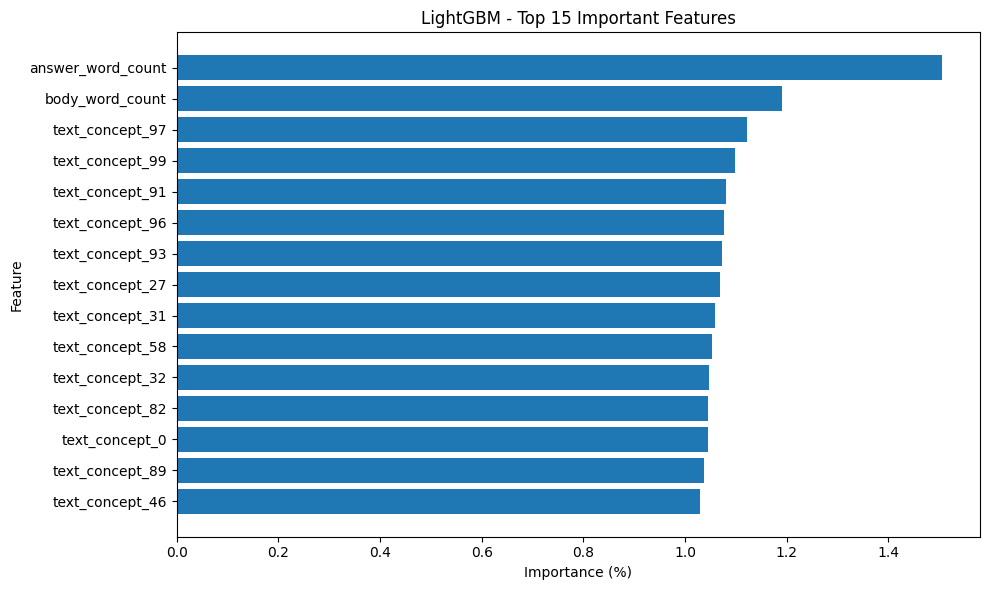

Saved: feature_importance_lightgbm.csv

=== XGBoost Top 15 Feature Importance ===


,feature,importance,importance_pct
0,queue_Technical Support,0.083503,8.350269
1,queue_IT Support,0.061628,6.162795
2,queue_Service Outages and Maintenance,0.061114,6.111356
3,queue_Human Resources,0.031368,3.136825
4,has_urgency_keyword,0.030126,3.012613
5,queue_Customer Service,0.028375,2.837530
6,queue_General Inquiry,0.026483,2.648272
7,subject_word_count,0.024462,2.446200
8,queue_Sales and Pre-Sales,0.023805,2.380469
9,queue_Returns and Exchanges,0.023170,2.317014


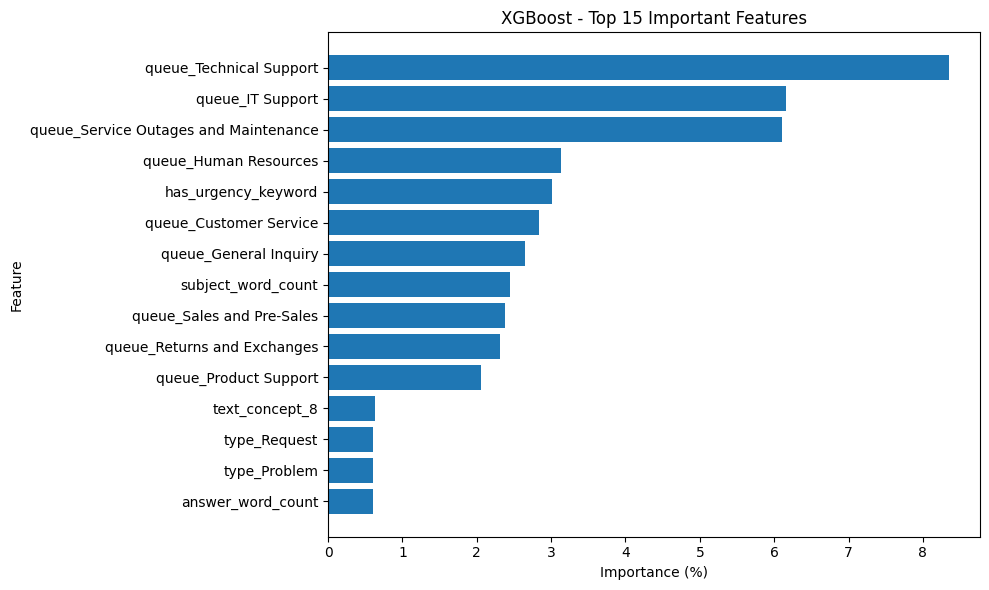

Saved: feature_importance_xgboost.csv

=== Consensus Top Features Across Tree Models ===


,feature,RandomForest_importance_pct,LightGBM_importance_pct,XGBoost_importance_pct,consensus_importance_pct
0,queue_Technical Support,3.515254,0.232804,8.350269,4.032776
1,queue_IT Support,1.112194,0.173091,6.162795,2.482694
2,queue_Service Outages and Maintenance,0.784702,0.152305,6.111356,2.349455
3,queue_Customer Service,1.681352,0.154573,2.837530,1.557818
4,subject_word_count,0.743730,0.808390,2.446200,1.332773
5,queue_Human Resources,0.736880,0.121693,3.136825,1.331799
6,has_urgency_keyword,0.441285,0.066893,3.012613,1.173597
7,queue_General Inquiry,0.534313,0.113379,2.648272,1.098654
8,answer_word_count,1.019443,1.504913,0.605936,1.043431
9,queue_Returns and Exchanges,0.517713,0.111867,2.317014,0.982198


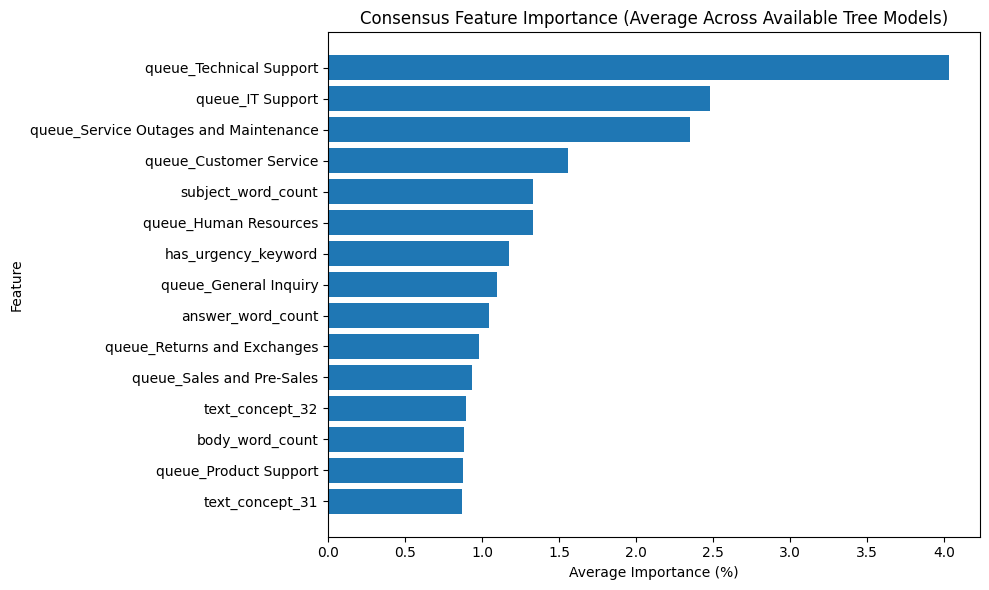

Saved: feature_importance_consensus_tree_models.csv

Interpretation note: features appearing repeatedly at the top across models are typically the most stable drivers of priority prediction.


In [ ]:
# 5.1 Tree-Based Feature Importance and Interpretation

if 'X_train_resampled' not in globals():
    raise ValueError("X_train_resampled not found. Run train/SMOTE cells first.")

feature_names = X_train_resampled.columns.tolist()

tree_models = {
    'RandomForest': globals().get('rf_model', None),
    'LightGBM': globals().get('lgbm_model', None),
    'XGBoost': globals().get('xgb_model', None)
}

importance_tables = {}

for model_name, model_obj in tree_models.items():
    if model_obj is None:
        print(f"{model_name} skipped: model not found in memory.")
        continue

    if not hasattr(model_obj, 'feature_importances_'):
        print(f"{model_name} skipped: feature_importances_ not available.")
        continue

    raw_importance = np.array(model_obj.feature_importances_, dtype=float)
    if len(raw_importance) != len(feature_names):
        print(f"{model_name} skipped: feature length mismatch ({len(raw_importance)} vs {len(feature_names)}).")
        continue

    imp_df = pd.DataFrame({
        'feature': feature_names,
        'importance': raw_importance
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    # Normalized percentage for easier non-technical reporting
    total_imp = imp_df['importance'].sum()
    imp_df['importance_pct'] = (imp_df['importance'] / total_imp * 100.0) if total_imp > 0 else 0.0

    importance_tables[model_name] = imp_df

if not importance_tables:
    raise ValueError("No tree-based model feature importance found. Train at least one of RF/LightGBM/XGBoost first.")

# Display and visualize top features per model
TOP_N = 15
for model_name, imp_df in importance_tables.items():
    print(f"\n=== {model_name} Top {TOP_N} Feature Importance ===")
    top_df = imp_df.head(TOP_N).copy()
    display(top_df)

    plt.figure(figsize=(10, 6))
    plot_df = top_df.iloc[::-1]
    plt.barh(plot_df['feature'], plot_df['importance_pct'])
    plt.title(f"{model_name} - Top {TOP_N} Important Features")
    plt.xlabel('Importance (%)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    # Export per-model ranking table
    out_name = f"feature_importance_{model_name.lower()}.csv"
    imp_df.to_csv(out_name, index=False)
    print(f"Saved: {out_name}")

# Consensus ranking across available tree models
consensus_rows = []
for model_name, imp_df in importance_tables.items():
    temp = imp_df[['feature', 'importance_pct']].copy()
    temp = temp.rename(columns={'importance_pct': f'{model_name}_importance_pct'})
    consensus_rows.append(temp)

consensus_df = consensus_rows[0]
for i in range(1, len(consensus_rows)):
    consensus_df = consensus_df.merge(consensus_rows[i], on='feature', how='outer')

consensus_df = consensus_df.fillna(0)
model_pct_cols = [c for c in consensus_df.columns if c.endswith('_importance_pct')]
consensus_df['consensus_importance_pct'] = consensus_df[model_pct_cols].mean(axis=1)
consensus_df = consensus_df.sort_values('consensus_importance_pct', ascending=False).reset_index(drop=True)

print("\n=== Consensus Top Features Across Tree Models ===")
display(consensus_df.head(TOP_N))

plt.figure(figsize=(10, 6))
consensus_plot = consensus_df.head(TOP_N).iloc[::-1]
plt.barh(consensus_plot['feature'], consensus_plot['consensus_importance_pct'])
plt.title('Consensus Feature Importance (Average Across Available Tree Models)')
plt.xlabel('Average Importance (%)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

consensus_df.to_csv('feature_importance_consensus_tree_models.csv', index=False)
print("Saved: feature_importance_consensus_tree_models.csv")

print("\nInterpretation note: features appearing repeatedly at the top across models are typically the most stable drivers of priority prediction.")

## Actual vs Predicted Plot (Classification)

This section compares **actual** and **predicted** class counts for the selected evaluation model.

- Deliverable target: *Actual vs. Predicted Plot*
- Output: grouped bar chart + export table for reporting

Using predictions from: LightGBM


,class_id,class_label,actual_count,predicted_count
0,0,Low (0),884,619
1,1,Medium (1),1728,1898
2,2,High (2),1677,1772


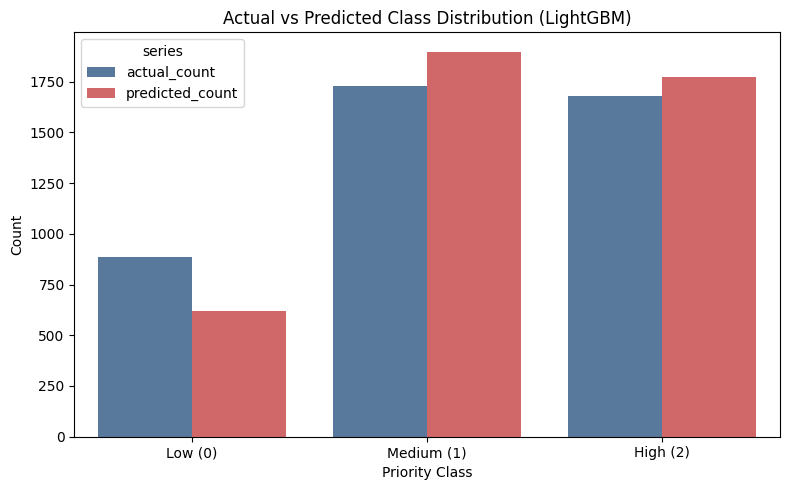

Saved: actual_vs_predicted_class_counts.csv


In [ ]:
# Actual vs Predicted Class Distribution

if 'y_val' not in globals():
    raise ValueError("y_val not found. Run split/model evaluation cells first.")

# Pick the best available prediction source using your notebook's existing variables.
pred_priority = [
    ('LightGBM', 'y_val_pred_lgbm'),
    ('RandomForest', 'y_val_pred_rf'),
    ('XGBoost', 'y_val_pred_xgb'),
    ('LogisticRegression', 'y_val_pred_logreg'),
    ('LinearSVC', 'y_val_pred_linear_svc')
]

selected_model = None
y_pred_selected = None
for model_name, pred_var in pred_priority:
    if pred_var in globals():
        selected_model = model_name
        y_pred_selected = globals()[pred_var]
        break

if y_pred_selected is None:
    raise ValueError("No prediction vector found. Run at least one model evaluation cell first.")

label_map = {0: 'Low (0)', 1: 'Medium (1)', 2: 'High (2)'}
class_order = [0, 1, 2]

actual_counts = pd.Series(y_val).value_counts().reindex(class_order, fill_value=0)
pred_counts = pd.Series(y_pred_selected).value_counts().reindex(class_order, fill_value=0)

actual_vs_pred_df = pd.DataFrame({
    'class_id': class_order,
    'class_label': [label_map[c] for c in class_order],
    'actual_count': actual_counts.values,
    'predicted_count': pred_counts.values
})

print(f"Using predictions from: {selected_model}")
display(actual_vs_pred_df)

plot_df = actual_vs_pred_df.melt(
    id_vars=['class_label'],
    value_vars=['actual_count', 'predicted_count'],
    var_name='series',
    value_name='count'
)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x='class_label', y='count', hue='series', palette=['#4E79A7', '#E15759'])
plt.title(f'Actual vs Predicted Class Distribution ({selected_model})')
plt.xlabel('Priority Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

actual_vs_pred_df.to_csv('actual_vs_predicted_class_counts.csv', index=False)
print('Saved: actual_vs_predicted_class_counts.csv')

## Classification Error Analysis (Residual Equivalent)

For classification problems, this replaces residual plots with **misclassification diagnostics**.

- Deliverable target: *Residual Analysis Report (classification equivalent)*
- Outputs:
  1. Class-wise FP/FN table
  2. High-priority error-focus chart
  3. Exportable error report CSV

Error analysis based on model: LightGBM


,class_id,class_label,TP,FP,FN,TN,precision,recall,class_error_rate_vs_total
0,0,Low (0),414,205,470,3200,0.6688,0.4683,0.1574
1,1,Medium (1),1232,666,496,1895,0.6491,0.7130,0.2709
2,2,High (2),1245,527,432,2085,0.7026,0.7424,0.2236



TP/FN/FP/TN Computation Logic by Class:


,class_id,class_label,actual_row_sum,pred_col_sum,total_samples,TP_logic,FN_logic,FP_logic,TN_logic
0,0,Low (0),884,619,4289,"cm[0,0] = 414",row_sum - TP = 884 - 414 = 470,col_sum - TP = 619 - 414 = 205,total - (TP+FN+FP) = 4289 - (414+470+205) = 3200
1,1,Medium (1),1728,1898,4289,"cm[1,1] = 1232",row_sum - TP = 1728 - 1232 = 496,col_sum - TP = 1898 - 1232 = 666,total - (TP+FN+FP) = 4289 - (1232+496+666) = 1895
2,2,High (2),1677,1772,4289,"cm[2,2] = 1245",row_sum - TP = 1677 - 1245 = 432,col_sum - TP = 1772 - 1245 = 527,total - (TP+FN+FP) = 4289 - (1245+432+527) = 2085



Plain-language TP/FN/FP explanations (Low, Medium, High):


,Class,Metric,Explanation
0,Low,TP(Low),Actual Low predicted Low = 414
1,Low,FN(Low),Actual Low predicted Medium or High = 303 + 16...
2,Low,FP(Low),Actual Medium or High predicted Low = 136 + 69...
3,Medium,TP(Medium),Actual Medium predicted Medium = 1232
4,Medium,FN(Medium),Actual Medium predicted Low or High = 136 + 36...
5,Medium,FP(Medium),Actual Low or High predicted Medium = 303 + 36...
6,High,TP(High),Actual High predicted High = 1245
7,High,FN(High),Actual High predicted Low or Medium = 69 + 363...
8,High,FP(High),Actual Low or Medium predicted High = 167 + 36...


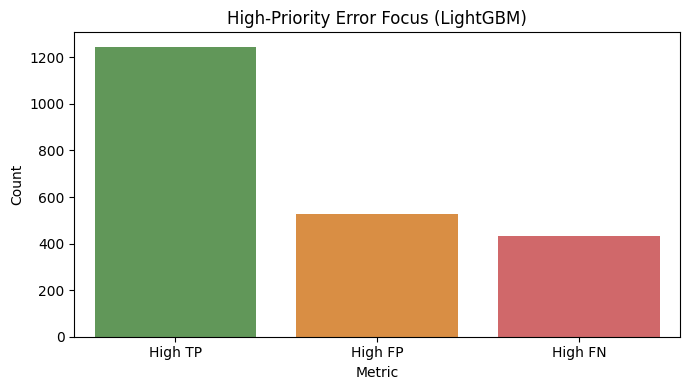

Total misclassified rows: 1398


,actual,predicted,actual_label,predicted_label
0,1,2,Medium (1),High (2)
1,2,1,High (2),Medium (1)
2,1,2,Medium (1),High (2)
3,0,2,Low (0),High (2)
4,0,1,Low (0),Medium (1)
5,1,2,Medium (1),High (2)
6,2,1,High (2),Medium (1)
7,0,1,Low (0),Medium (1)
8,0,2,Low (0),High (2)
9,1,2,Medium (1),High (2)


Saved: classification_error_analysis_report.csv


In [ ]:
# 5.3 Code: Misclassification Diagnostics (Residual Equivalent)

if 'y_val' not in globals():
    raise ValueError("y_val not found. Run split/model evaluation cells first.")

# Reuse the same selected prediction from 5.2 if available; otherwise select again.
if 'y_pred_selected' not in globals() or y_pred_selected is None:
    pred_priority = [
        ('LightGBM', 'y_val_pred_lgbm'),
        ('RandomForest', 'y_val_pred_rf'),
        ('XGBoost', 'y_val_pred_xgb'),
        ('LogisticRegression', 'y_val_pred_logreg'),
        ('LinearSVC', 'y_val_pred_linear_svc')
    ]
    selected_model = None
    y_pred_selected = None
    for model_name, pred_var in pred_priority:
        if pred_var in globals():
            selected_model = model_name
            y_pred_selected = globals()[pred_var]
            break

if y_pred_selected is None:
    raise ValueError("No prediction vector found. Run at least one model evaluation cell first.")

label_map = {0: 'Low (0)', 1: 'Medium (1)', 2: 'High (2)'}
short_label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
class_order = [0, 1, 2]

cm = confusion_matrix(y_val, y_pred_selected, labels=class_order)
total = int(cm.sum())
row_sums = cm.sum(axis=1)  # Actual-class totals
col_sums = cm.sum(axis=0)  # Predicted-class totals

rows = []
logic_rows = []
explain_rows = []
for i, cls in enumerate(class_order):
    tp = int(cm[i, i])

    other_cols = [j for j in class_order if j != i]
    other_rows = [j for j in class_order if j != i]

    fn_part_1 = int(cm[i, other_cols[0]])
    fn_part_2 = int(cm[i, other_cols[1]])
    fn = int(fn_part_1 + fn_part_2)

    fp_part_1 = int(cm[other_rows[0], i])
    fp_part_2 = int(cm[other_rows[1], i])
    fp = int(fp_part_1 + fp_part_2)

    tn = int(total - (tp + fn + fp))

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    error_rate = (fp + fn) / total if total else 0.0

    rows.append({
        'class_id': cls,
        'class_label': label_map[cls],
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'precision': precision,
        'recall': recall,
        'class_error_rate_vs_total': error_rate
    })

    logic_rows.append({
        'class_id': cls,
        'class_label': label_map[cls],
        'actual_row_sum': int(row_sums[i]),
        'pred_col_sum': int(col_sums[i]),
        'total_samples': total,
        'TP_logic': f"cm[{i},{i}] = {tp}",
        'FN_logic': f"row_sum - TP = {int(row_sums[i])} - {tp} = {fn}",
        'FP_logic': f"col_sum - TP = {int(col_sums[i])} - {tp} = {fp}",
        'TN_logic': f"total - (TP+FN+FP) = {total} - ({tp}+{fn}+{fp}) = {tn}"
    })

    explain_rows.extend([
        {
            'Class': short_label_map[cls],
            'Metric': f"TP({short_label_map[cls]})",
            'Explanation': f"Actual {short_label_map[cls]} predicted {short_label_map[cls]} = {tp}"
        },
        {
            'Class': short_label_map[cls],
            'Metric': f"FN({short_label_map[cls]})",
            'Explanation': (
                f"Actual {short_label_map[cls]} predicted {short_label_map[other_cols[0]]} or {short_label_map[other_cols[1]]} = "
                f"{fn_part_1} + {fn_part_2} = {fn}"
            )
        },
        {
            'Class': short_label_map[cls],
            'Metric': f"FP({short_label_map[cls]})",
            'Explanation': (
                f"Actual {short_label_map[other_rows[0]]} or {short_label_map[other_rows[1]]} predicted {short_label_map[cls]} = "
                f"{fp_part_1} + {fp_part_2} = {fp}"
            )
        }
    ])

error_report_df = pd.DataFrame(rows)
logic_df = pd.DataFrame(logic_rows)
explain_df = pd.DataFrame(explain_rows)

print(f"Error analysis based on model: {selected_model}")
display(error_report_df.round(4))

print("\nTP/FN/FP/TN Computation Logic by Class:")
display(logic_df)

print("\nPlain-language TP/FN/FP explanations (Low, Medium, High):")
display(explain_df)

# Focus chart for critical class risk (High = 2)
high_row = error_report_df[error_report_df['class_id'] == 2].iloc[0]
focus_df = pd.DataFrame({
    'metric': ['High TP', 'High FP', 'High FN'],
    'value': [high_row['TP'], high_row['FP'], high_row['FN']]
})

plt.figure(figsize=(7, 4))
sns.barplot(data=focus_df, x='metric', y='value', palette=['#59A14F', '#F28E2B', '#E15759'])
plt.title(f'High-Priority Error Focus ({selected_model})')
plt.xlabel('Metric')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Optional detailed misclassified sample view (if source columns are available)
if 'X_val' in globals():
    try:
        mis_idx = np.where(np.array(y_val) != np.array(y_pred_selected))[0]
        mis_summary = pd.DataFrame({
            'actual': np.array(y_val)[mis_idx],
            'predicted': np.array(y_pred_selected)[mis_idx]
        })
        mis_summary['actual_label'] = mis_summary['actual'].map(label_map)
        mis_summary['predicted_label'] = mis_summary['predicted'].map(label_map)
        print(f"Total misclassified rows: {len(mis_summary)}")
        display(mis_summary.head(20))
    except Exception as e:
        print(f"Detailed misclassification preview skipped: {e}")

error_report_df.to_csv('classification_error_analysis_report.csv', index=False)
print('Saved: classification_error_analysis_report.csv')